# Catfish Multi-task Computer Vision — Google Colab

End-to-end, fish-grouped pipeline for growth-stage classification and SL/TL/weight regression. **357 image views are not 357 independent animals**: every split and confidence interval treats `fish_id` as the experimental unit.

Run once with `QUICK_MODE=True`. After it succeeds, set it to `False` for the controlled experiments. Use **Runtime → Change runtime type → T4 GPU**.

## 1. Colab setup and configuration

In [ ]:
import os, sys, subprocess, importlib.util
required = {"openpyxl":"openpyxl", "sklearn":"scikit-learn", "imblearn":"imbalanced-learn", "joblib":"joblib", "cv2":"opencv-python-headless", "seaborn":"seaborn"}
missing = [pkg for mod,pkg in required.items() if importlib.util.find_spec(mod) is None]
if missing:
    subprocess.check_call([sys.executable,"-m","pip","install","-q",*missing])

import gc, json, time, random, shutil, hashlib, warnings, zipfile
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from PIL import Image, UnidentifiedImageError
import cv2, joblib, tensorflow as tf
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, mean_absolute_error, mean_squared_error, r2_score)

QUICK_MODE = True
USE_GOOGLE_DRIVE = False
RESUME_FROM_CHECKPOINT = True
DEBUG_MODEL_LAYERS = False
RUN_CROPPING_EXPERIMENT = True
RUN_ALTERNATIVE_BACKBONE = True
RUN_REGRESSION = True
RUN_MULTITASK = True
RUN_CROSS_VALIDATION = False
RUN_GRADCAM = True
SEED, IMAGE_SIZE, BATCH_SIZE = 42, 224, 16
HEAD_EPOCHS = 2 if QUICK_MODE else 12
FINE_EPOCHS = 1 if QUICK_MODE else 10
CV_FOLDS = 3
CLASS_NAMES = ["Fingerling","Juvenile","Adult"]
CLASS_MAPPING = {n:i for i,n in enumerate(CLASS_NAMES)}
ROOT=Path("/content"); OUTPUTS=ROOT/"outputs"
for d in ["data","models","reports","figures","predictions","histories","explainability","scalers","crops"]:
    (OUTPUTS/d).mkdir(parents=True,exist_ok=True)
random.seed(SEED); np.random.seed(SEED); tf.keras.utils.set_random_seed(SEED)
try: tf.config.experimental.enable_op_determinism()
except Exception: pass
gpus=tf.config.list_physical_devices("GPU")
if gpus:
    try: tf.keras.mixed_precision.set_global_policy("mixed_float16")
    except Exception as e: print("Mixed precision unavailable:",e)
print("Python:",sys.version); print("TensorFlow:",tf.__version__); print("Devices:",tf.config.list_physical_devices())
print("GPU:",gpus[0].name if gpus else "None (CPU runtime)","| policy:",tf.keras.mixed_precision.global_policy())
if USE_GOOGLE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")


Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
TensorFlow: 2.20.0
Devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU: /physical_device:GPU:0 | policy: <DTypePolicy "mixed_float16">


## 2. Upload the four source files

In [ ]:
EXPECTED={"catfish_dataset.zip","adult.xlsx","juvenile.xlsx","fingerling.xlsx"}
if USE_GOOGLE_DRIVE:
    DRIVE_INPUT=Path("/content/drive/MyDrive/catfish_inputs")
    for name in EXPECTED:
        src=DRIVE_INPUT/name
        if src.exists(): shutil.copy2(src,ROOT/name)
else:
    from google.colab import files
    print("Upload:",sorted(EXPECTED)); uploaded=files.upload()
missing=sorted(name for name in EXPECTED if not (ROOT/name).is_file())
if missing: raise FileNotFoundError(f"Missing required upload(s): {missing}")
print("All required files are present.")


Upload: ['adult.xlsx', 'catfish_dataset.zip', 'fingerling.xlsx', 'juvenile.xlsx']


Saving fingerling.xlsx to fingerling.xlsx
All required files are present.


## 3. Extract and audit images

In [ ]:
EXTRACT=ROOT/"catfish_dataset"
if EXTRACT.exists(): shutil.rmtree(EXTRACT)
EXTRACT.mkdir()
with zipfile.ZipFile(ROOT/"catfish_dataset.zip") as z:
    bad=z.testzip()
    if bad: raise zipfile.BadZipFile(f"Corrupt ZIP member: {bad}")
    z.extractall(EXTRACT)
IMAGE_EXT={".jpg",".jpeg",".png",".bmp",".webp"}
all_files=[p for p in EXTRACT.rglob("*") if p.is_file()]
image_paths=[p for p in all_files if p.suffix.lower() in IMAGE_EXT]
unsupported=[p for p in all_files if p.suffix.lower() not in IMAGE_EXT and p.name!=".DS_Store"]
fish_dirs=sorted({p.parent for p in image_paths})
empty_dirs=[p for p in EXTRACT.rglob("*") if p.is_dir() and not any(x.is_file() for x in p.iterdir())]

def canonical_id(class_name, folder):
    digits=''.join(c for c in folder if c.isdigit())
    return f"{class_name.lower()}_{int(digits):03d}" if digits else f"{class_name.lower()}_{folder.lower().strip()}"

rows=[]
for p in sorted(image_paths):
    cls=p.parent.parent.name.strip().lower(); fish_id=canonical_id(cls,p.parent.name)
    rec=dict(fish_id=fish_id,image_path=str(p),filename=p.name,class_name=cls,source_folder=str(p.parent),valid=False,width=np.nan,height=np.nan,sha256="",error="")
    try:
        raw=p.read_bytes()
        with Image.open(p) as im: im.verify()
        with Image.open(p) as im: rec.update(valid=True,width=im.width,height=im.height,sha256=hashlib.sha256(raw).hexdigest())
    except Exception as e: rec["error"]=repr(e)
    rows.append(rec)
audit_images=pd.DataFrame(rows)
dup= audit_images[audit_images.duplicated("sha256",False)].sort_values("sha256")
cross_fish=dup.groupby("sha256").fish_id.nunique(); cross_fish=cross_fish[cross_fish>1]
cross_class=dup.groupby("sha256").class_name.nunique(); cross_class=cross_class[cross_class>1]
audit_table=pd.DataFrame({
 "metric":["images","valid_images","corrupt_images","fish_folders","empty_folders","unsupported_files","exact_duplicate_groups","duplicates_across_fish","duplicates_across_classes"],
 "value":[len(audit_images),int(audit_images.valid.sum()),int((~audit_images.valid).sum()),audit_images.fish_id.nunique(),len(empty_dirs),len(unsupported),dup.sha256.nunique(),len(cross_fish),len(cross_class)]})
display(audit_table); display(audit_images.groupby("class_name").agg(images=("image_path","size"),fish=("fish_id","nunique")))
if (~audit_images.valid).any(): display(audit_images[~audit_images.valid]); raise ValueError("Corrupt images found")
dup.to_csv(OUTPUTS/"reports/exact_duplicates.csv",index=False); audit_table.to_csv(OUTPUTS/"reports/dataset_audit.csv",index=False)


,metric,value
0,images,357
1,valid_images,357
2,corrupt_images,0
3,fish_folders,117
4,empty_folders,5
5,unsupported_files,1
6,exact_duplicate_groups,2
7,duplicates_across_fish,0
8,duplicates_across_classes,0


,images,fish
class_name,,
adult,104,33
fingerling,106,35
juvenile,147,49


## 4. Clean metadata and construct image-level index

In [ ]:
def read_metadata(path,class_name):
    raw=pd.read_excel(path,header=None)
    # Find the row containing the filename header, then use positional measurement columns.
    header_idx=next((i for i,row in raw.iterrows() if row.astype(str).str.lower().str.contains("filename").any()),1)
    d=raw.iloc[header_idx+1:,[0,3,4,5]].copy(); d.columns=["Filename","SL_cm","TL_cm","Weight_g"]
    d=d.dropna(how="all"); d["Filename"]=d.Filename.astype(str).str.strip()
    d["fish_id"]=[canonical_id(class_name,x) for x in d.Filename]
    d["class_name"]=class_name.lower(); d["class_label"]=CLASS_MAPPING[class_name]
    for c in ["SL_cm","TL_cm","Weight_g"]: d[c]=pd.to_numeric(d[c].astype(str).str.replace(",","",regex=False),errors="coerce")
    return d[["fish_id","Filename","SL_cm","TL_cm","Weight_g","class_name","class_label"]]

meta=pd.concat([read_metadata(ROOT/"fingerling.xlsx","Fingerling"),read_metadata(ROOT/"juvenile.xlsx","Juvenile"),read_metadata(ROOT/"adult.xlsx","Adult")],ignore_index=True)
conflicts=meta.groupby("fish_id")[["class_label","SL_cm","TL_cm","Weight_g"]].nunique().max(axis=1); conflicts=conflicts[conflicts>1]
if len(conflicts): display(meta[meta.fish_id.isin(conflicts.index)]); raise ValueError("Conflicting fish metadata")
if meta.fish_id.duplicated().any(): display(meta[meta.fish_id.duplicated(False)]); raise ValueError("Duplicate metadata fish IDs")
index=audit_images.drop(columns=["valid","error"]).merge(meta,on=["fish_id","class_name"],how="left",validate="many_to_one")
image_fish=set(index.fish_id); meta_fish=set(meta.fish_id)
unmatched_images=index[index.class_label.isna()]; unmatched_meta=meta[~meta.fish_id.isin(image_fish)]
if len(unmatched_images) or len(unmatched_meta):
    print("Unmatched images:"); display(unmatched_images); print("Unmatched metadata:"); display(unmatched_meta)
    raise ValueError("Image/metadata matching is incomplete")
index=index[["fish_id","image_path","filename","class_name","class_label","SL_cm","TL_cm","Weight_g","source_folder","width","height","sha256"]]
index.to_csv(OUTPUTS/"data/cleaned_dataset_index.csv",index=False); meta.to_csv(OUTPUTS/"data/fish_metadata_cleaned.csv",index=False)
print(f"Matched {len(index)} images to {index.fish_id.nunique()} fish")


Matched 357 images to 117 fish


## 5. Strict completed-dataset validation

In [ ]:
TARGETS=["SL_cm","TL_cm","Weight_g"]
assert index.image_path.map(lambda x:Path(x).is_file()).all()
assert index.class_label.notna().all() and index.fish_id.astype(bool).all()
assert index[TARGETS].notna().all().all()
assert all(pd.api.types.is_numeric_dtype(index[c]) for c in TARGETS)
assert (index[TARGETS]>0).all().all() and (index.SL_cm<index.TL_cm).all()
assert index.groupby("image_path").class_label.nunique().max()==1
assert index.groupby("fish_id")[["class_label",*TARGETS]].nunique().max().max()==1
print("All strict validation checks passed.")


All strict validation checks passed.


## 6. Exploratory data analysis

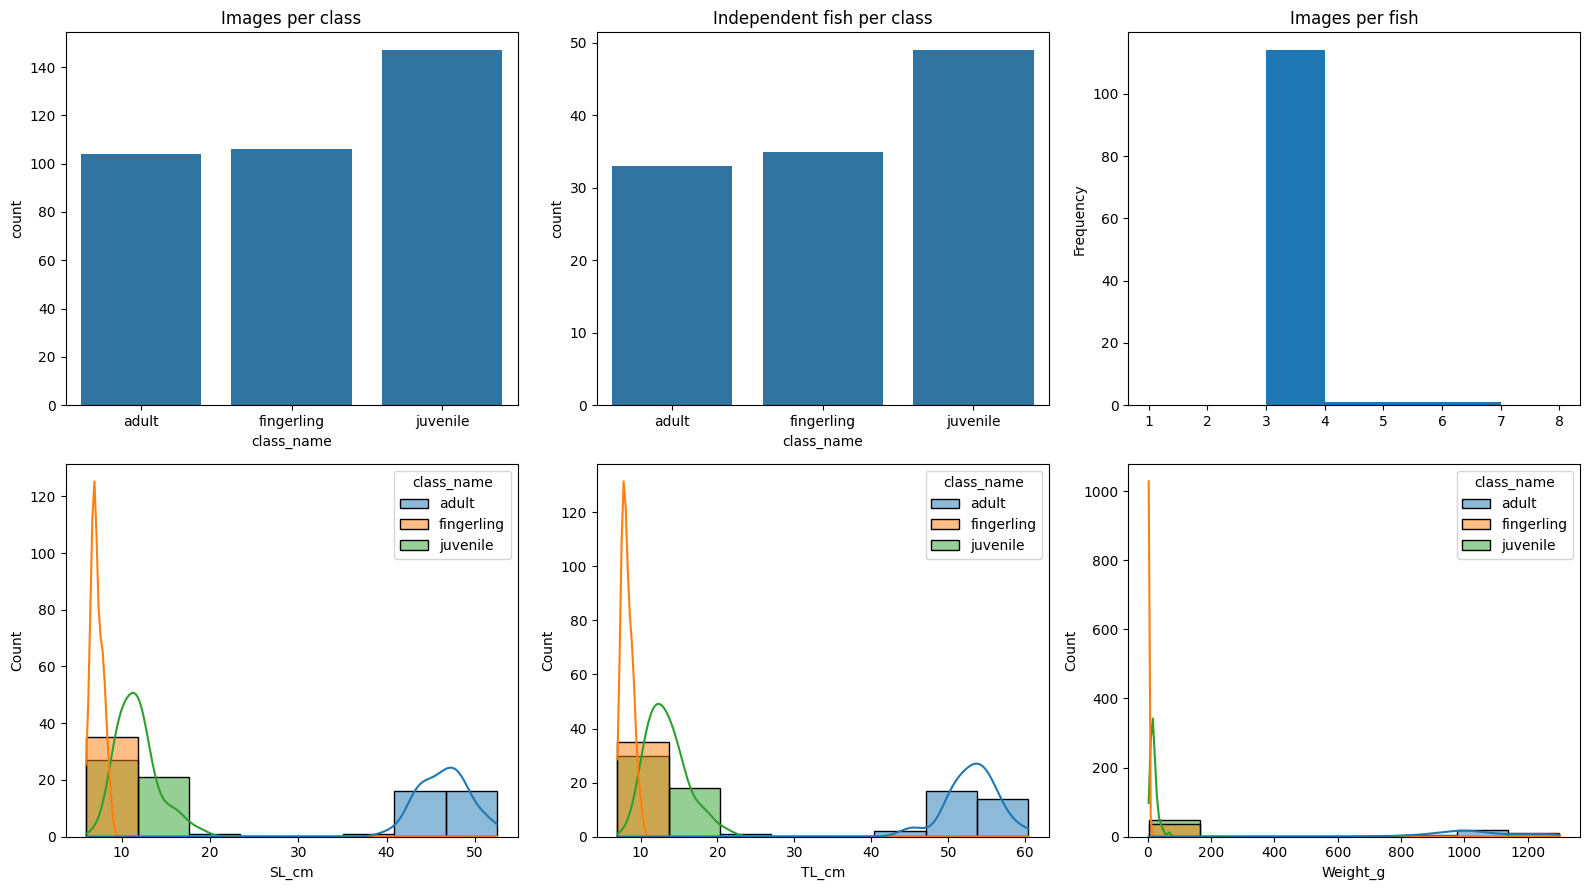

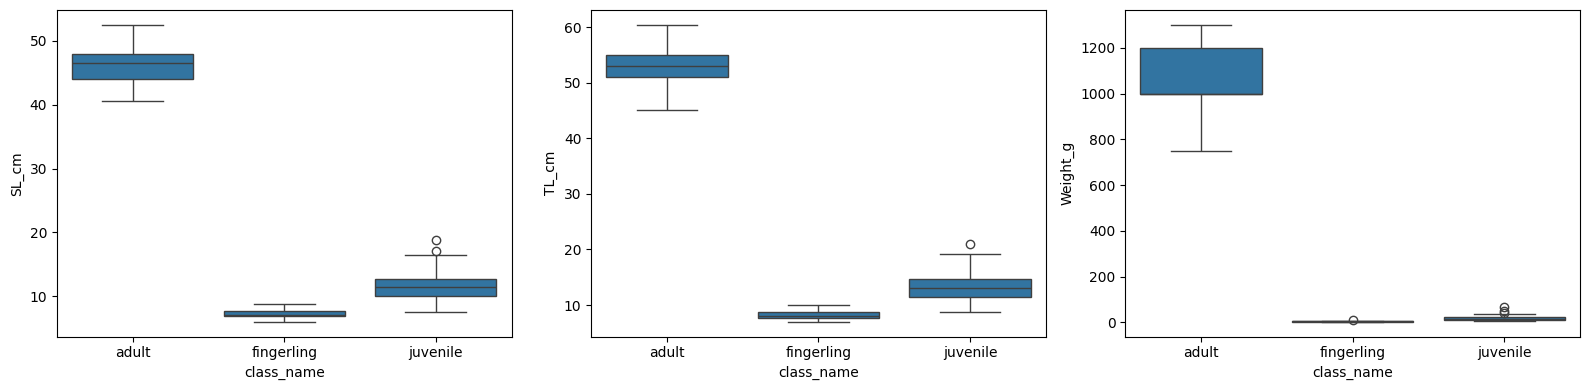

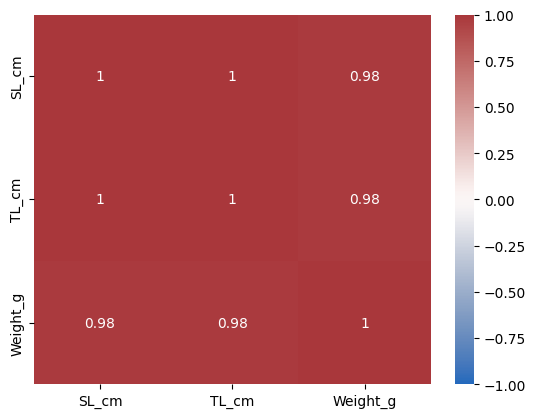

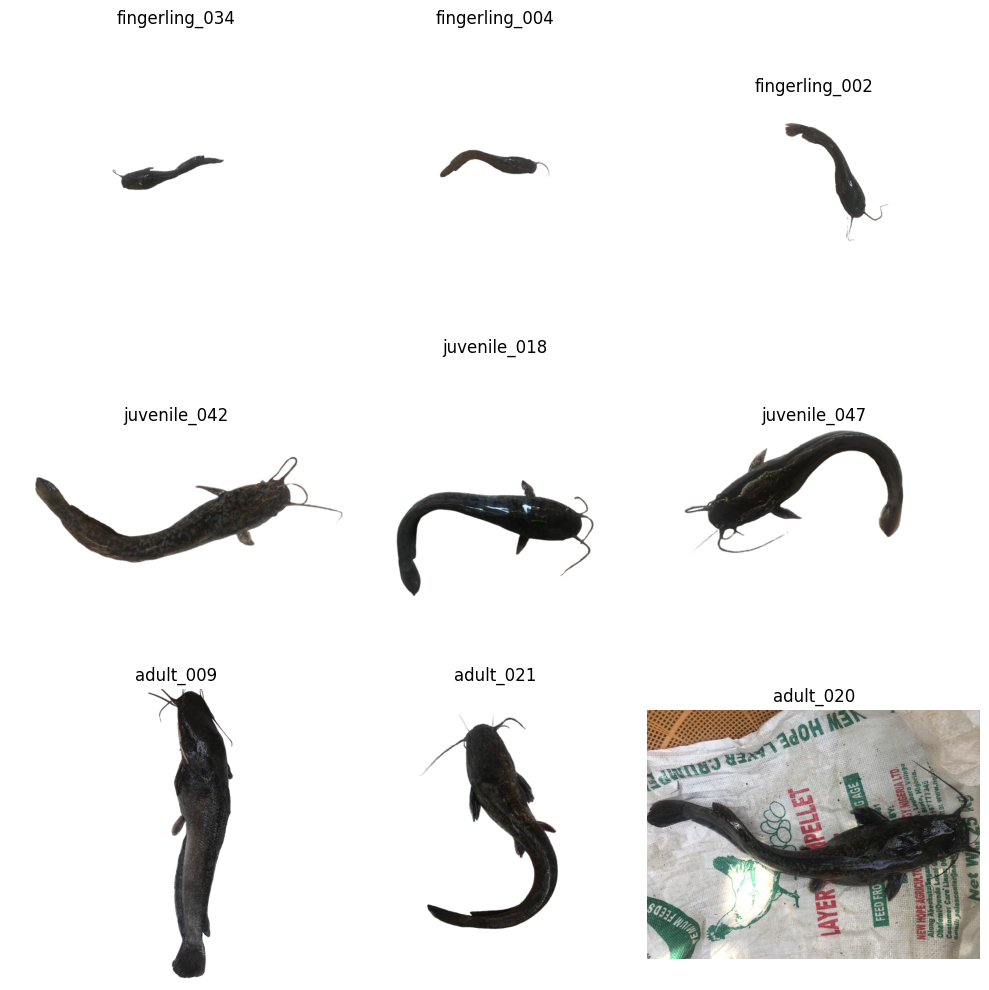

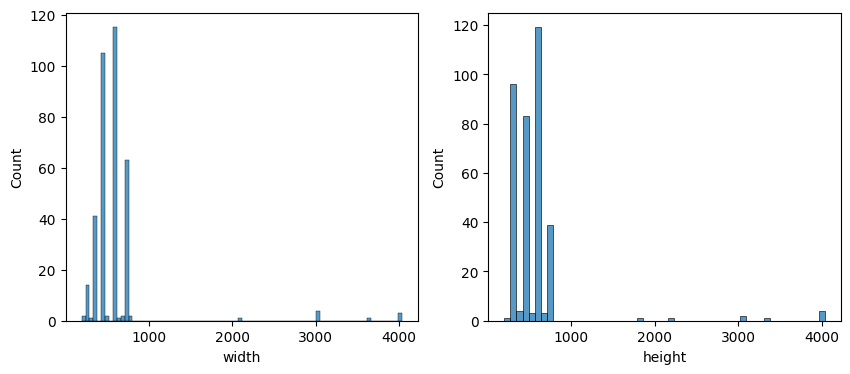

Fingerling/juvenile overlap: {'SL_cm': (8.7, 7.5), 'TL_cm': (10.0, 8.8), 'Weight_g': (8.5, 5.4)}


In [ ]:
fish=index.drop_duplicates("fish_id")
fig,ax=plt.subplots(2,3,figsize=(16,9))
sns.countplot(data=index,x="class_name",ax=ax[0,0]); ax[0,0].set_title("Images per class")
sns.countplot(data=fish,x="class_name",ax=ax[0,1]); ax[0,1].set_title("Independent fish per class")
index.groupby("fish_id").size().plot.hist(bins=range(1,9),ax=ax[0,2]); ax[0,2].set_title("Images per fish")
for c,a in zip(TARGETS,ax[1]): sns.histplot(data=fish,x=c,hue="class_name",kde=True,ax=a)
plt.tight_layout(); plt.savefig(OUTPUTS/"figures/eda_distributions.png",dpi=160); plt.show()
fig,ax=plt.subplots(1,3,figsize=(16,4))
for c,a in zip(TARGETS,ax): sns.boxplot(data=fish,x="class_name",y=c,ax=a)
plt.tight_layout(); plt.savefig(OUTPUTS/"figures/measurement_boxplots.png",dpi=160); plt.show()
sns.heatmap(fish[TARGETS].corr(),annot=True,cmap="vlag",vmin=-1,vmax=1); plt.savefig(OUTPUTS/"figures/correlation.png",dpi=160); plt.show()
fig,axes=plt.subplots(3,3,figsize=(10,10))
for r,cls in enumerate(["fingerling","juvenile","adult"]):
 for c,(_,row) in enumerate(index[index.class_name==cls].sample(3,random_state=SEED).iterrows()):
  axes[r,c].imshow(Image.open(row.image_path)); axes[r,c].set_title(row.fish_id); axes[r,c].axis("off")
plt.tight_layout(); plt.savefig(OUTPUTS/"figures/representative_images.png",dpi=160); plt.show()
fig,ax=plt.subplots(1,2,figsize=(10,4)); sns.histplot(index.width,ax=ax[0]); sns.histplot(index.height,ax=ax[1]); plt.show()
print("Fingerling/juvenile overlap:", {c:(fish[fish.class_name=="fingerling"][c].max(),fish[fish.class_name=="juvenile"][c].min()) for c in TARGETS})


## 7. Stratified fish-grouped 70/15/15 split and leakage proof

In [ ]:
def grouped_split(df,seed=SEED):
    f=df[["fish_id","class_label"]].drop_duplicates()
    rng=np.random.default_rng(seed); assignment={"train":[],"validation":[],"test":[]}
    for label,g in f.groupby("class_label"):
        ids=g.fish_id.to_numpy().copy(); rng.shuffle(ids); n=len(ids); nt=round(.70*n); nv=round(.15*n)
        assignment["train"] += ids[:nt].tolist(); assignment["validation"] += ids[nt:nt+nv].tolist(); assignment["test"] += ids[nt+nv:].tolist()
    return {k:df[df.fish_id.isin(v)].copy().reset_index(drop=True) for k,v in assignment.items()}
splits=grouped_split(index); train,val,test=splits["train"],splits["validation"],splits["test"]
ids={k:set(v.fish_id) for k,v in splits.items()}
assert ids["train"].isdisjoint(ids["validation"]) and ids["train"].isdisjoint(ids["test"]) and ids["validation"].isdisjoint(ids["test"])
hashes={k:set(v.sha256) for k,v in splits.items()}
assert hashes["train"].isdisjoint(hashes["validation"]) and hashes["train"].isdisjoint(hashes["test"]) and hashes["validation"].isdisjoint(hashes["test"])
for name,d in splits.items():
    d.to_csv(OUTPUTS/f"data/{name}_split.csv",index=False)
    print("\n",name,"images",len(d),"fish",d.fish_id.nunique()); print("images/class",d.class_name.value_counts().to_dict()); print("fish/class",d.groupby("class_name").fish_id.nunique().to_dict()); display(d[TARGETS].describe())
print("PASS: zero fish overlap and zero exact duplicate hashes across splits")



 train images 249 fish 81
images/class {'juvenile': 102, 'adult': 74, 'fingerling': 73}
fish/class {'adult': 23, 'fingerling': 24, 'juvenile': 34}


,SL_cm,TL_cm,Weight_g
count,249.000000,249.000000,249.000000
mean,20.693173,23.691566,316.515663
std,16.982213,19.473302,473.099351
min,6.200000,7.000000,2.800000
25%,7.600000,8.800000,5.400000
50%,11.600000,13.100000,16.900000
75%,43.500000,50.400000,1000.000000
max,52.500000,60.400000,1300.000000



 validation images 51 fish 17
images/class {'juvenile': 21, 'adult': 15, 'fingerling': 15}
fish/class {'adult': 5, 'fingerling': 5, 'juvenile': 7}


,SL_cm,TL_cm,Weight_g
count,51.000000,51.000000,51.000000
mean,20.452941,23.088235,309.229412
std,16.932624,19.007184,472.655801
min,6.000000,7.400000,2.900000
25%,8.200000,9.200000,6.000000
50%,11.000000,12.500000,15.700000
75%,43.000000,45.800000,850.000000
max,50.500000,57.000000,1250.000000



 test images 57 fish 19
images/class {'juvenile': 24, 'fingerling': 18, 'adult': 15}
fish/class {'adult': 5, 'fingerling': 6, 'juvenile': 8}


,SL_cm,TL_cm,Weight_g
count,57.000000,57.000000,57.000000
mean,19.810526,22.552632,298.536842
std,16.836119,19.242875,487.416450
min,6.900000,7.600000,4.100000
25%,8.200000,9.200000,7.500000
50%,10.300000,11.800000,11.500000
75%,46.000000,53.000000,1000.000000
max,49.000000,56.500000,1250.000000


PASS: zero fish overlap and zero exact duplicate hashes across splits


## 8–10. Train-only target scaling, realistic augmentation, and `tf.data`

Raw image range: 0.0 255.0
Augmented image range: -0.09173583984375 255.125


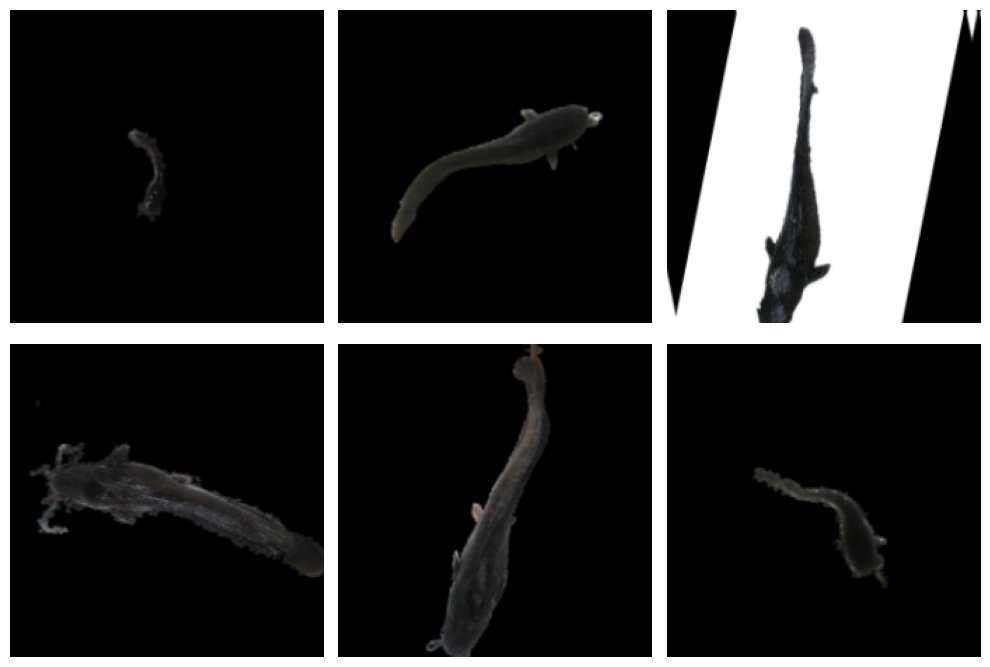

In [ ]:
sl_scaler = StandardScaler().fit(train[["SL_cm"]])
tl_scaler = StandardScaler().fit(train[["TL_cm"]])
weight_scaler = StandardScaler().fit(
    np.log1p(train[["Weight_g"]])
)

joblib.dump(
    sl_scaler,
    OUTPUTS / "scalers/sl_scaler.joblib"
)
joblib.dump(
    tl_scaler,
    OUTPUTS / "scalers/tl_scaler.joblib"
)
joblib.dump(
    weight_scaler,
    OUTPUTS / "scalers/weight_log_scaler.joblib"
)


def scaled_targets(d):
    sl_scaled = sl_scaler.transform(
        d[["SL_cm"]]
    )[:, 0]

    tl_scaled = tl_scaler.transform(
        d[["TL_cm"]]
    )[:, 0]

    weight_scaled = weight_scaler.transform(
        np.log1p(d[["Weight_g"]])
    )[:, 0]

    return np.column_stack([
        sl_scaled,
        tl_scaled,
        weight_scaled
    ]).astype("float32")


augment = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.045),
        tf.keras.layers.RandomTranslation(
            height_factor=0.05,
            width_factor=0.05
        ),
        tf.keras.layers.RandomZoom(
            height_factor=0.08,
            width_factor=0.08
        ),
        tf.keras.layers.RandomContrast(0.08),

        # Keras 3 expects stddev between 0 and 1.
        tf.keras.layers.GaussianNoise(0.02),
    ],
    name="moderate_augmentation"
)


def decode(path, label, targets):
    image_bytes = tf.io.read_file(path)

    image = tf.io.decode_image(
        image_bytes,
        channels=3,
        expand_animations=False
    )

    image = tf.image.resize_with_pad(
        image,
        IMAGE_SIZE,
        IMAGE_SIZE
    )

    image = tf.cast(image, tf.float32)

    image.set_shape([
        IMAGE_SIZE,
        IMAGE_SIZE,
        3
    ])

    return image, {
        "class_output": label,
        "reg_output": targets
    }


def make_ds(
    d,
    training=False,
    batch_size=BATCH_SIZE,
    path_col="image_path"
):
    image_paths = d[path_col].astype(str).values

    class_labels = d["class_label"].astype(
        "int32"
    ).values

    regression_targets = scaled_targets(d)

    ds = tf.data.Dataset.from_tensor_slices(
        (
            image_paths,
            class_labels,
            regression_targets
        )
    )

    ds = ds.map(
        decode,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    if training:
        ds = ds.shuffle(
            buffer_size=len(d),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    ds = ds.batch(batch_size)

    ds = ds.prefetch(
        tf.data.AUTOTUNE
    )

    return ds


@tf.autograph.experimental.do_not_convert
def extract_classification_target(images, targets):
    return images, targets["class_output"]


def classification_ds(ds):
    return ds.map(
        extract_classification_target,
        num_parallel_calls=tf.data.AUTOTUNE
    )


train_ds = make_ds(
    train,
    training=True
)

val_ds = make_ds(val)

test_ds = make_ds(test)


xb, _ = next(iter(train_ds))

augmented_images = augment(
    xb[:6],
    training=True
)

print(
    "Raw image range:",
    float(tf.reduce_min(xb)),
    float(tf.reduce_max(xb))
)

print(
    "Augmented image range:",
    float(tf.reduce_min(augmented_images)),
    float(tf.reduce_max(augmented_images))
)


fig, axes = plt.subplots(
    2,
    3,
    figsize=(10, 7)
)

for axis, image in zip(
    axes.flat,
    augmented_images
):
    display_image = tf.cast(
        tf.clip_by_value(
            image,
            0,
            255
        ),
        tf.uint8
    )

    axis.imshow(display_image)
    axis.axis("off")

plt.tight_layout()

plt.savefig(
    OUTPUTS / "figures/augmentation_examples.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## 11. Conservative label-free fish-centred crops

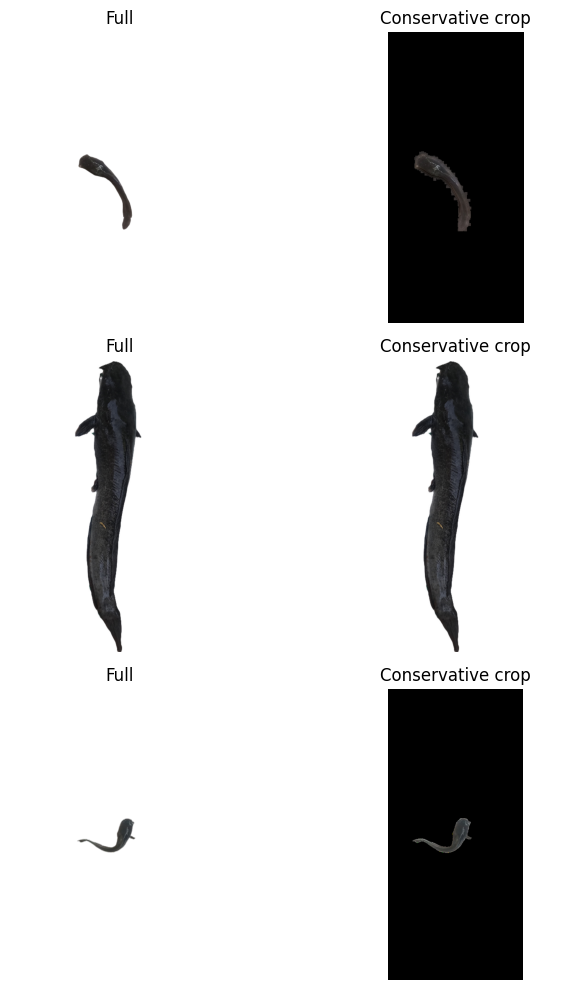

In [ ]:
def conservative_crop(src,dst):
    img=cv2.imread(str(src));
    if img is None: return False
    h,w=img.shape[:2]; gray=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY); blur=cv2.GaussianBlur(gray,(7,7),0)
    edges=cv2.Canny(blur,30,100); edges=cv2.morphologyEx(edges,cv2.MORPH_CLOSE,np.ones((15,15),np.uint8))
    cnts,_=cv2.findContours(edges,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
    if not cnts: crop=img
    else:
        x,y,bw,bh=cv2.boundingRect(max(cnts,key=cv2.contourArea)); pad=int(.12*max(bw,bh)); x=max(0,x-pad); y=max(0,y-pad); x2=min(w,x+bw+2*pad); y2=min(h,y+bh+2*pad)
        area=(x2-x)*(y2-y)
        crop=img[y:y2,x:x2] if area>=.25*h*w and (x2-x)>=.45*w and (y2-y)>=.20*h else img
    Path(dst).parent.mkdir(parents=True,exist_ok=True); return cv2.imwrite(str(dst),crop)
for d in [train,val,test]:
    paths=[]
    for _,r in d.iterrows():
        dst=OUTPUTS/"crops"/r.class_name/r.fish_id/r.filename
        if not dst.exists(): conservative_crop(r.image_path,dst)
        paths.append(str(dst))
    d["crop_path"]=paths
fig,ax=plt.subplots(3,2,figsize=(8,10))
for a,(_,r) in zip(ax,index.sample(3,random_state=SEED).iterrows()): pass
for i,(_,r) in enumerate(train.sample(3,random_state=SEED).iterrows()):
    ax[i,0].imshow(Image.open(r.image_path)); ax[i,0].set_title("Full"); ax[i,1].imshow(Image.open(r.crop_path)); ax[i,1].set_title("Conservative crop")
    ax[i,0].axis("off"); ax[i,1].axis("off")
plt.tight_layout(); plt.savefig(OUTPUTS/"figures/cropping_examples.png",dpi=150); plt.show()


## 12–16. Classification models, full-validation metrics, fine-tuning, and controlled experiments

In [ ]:
class BestMacroF1Checkpoint(tf.keras.callbacks.Callback):
    """One deterministic full-validation pass per epoch; saves on macro-F1 improvement."""
    def __init__(self,val_frame,val_dataset,save_path): super().__init__(); self.frame=val_frame; self.ds=val_dataset; self.save_path=Path(save_path); self.rows=[]; self.best=-np.inf; self.best_epoch=None; self.best_row=None
    def on_epoch_end(self,epoch,logs=None):
        logs=logs if logs is not None else {}
        out=self.model.predict(self.ds,verbose=0); prob=out[0] if isinstance(out,list) else out; pred=prob.argmax(1); y=self.frame.class_label.values
        pr,re,f1,_=precision_recall_fscore_support(y,pred,labels=[0,1,2],zero_division=0); row={"epoch":int(epoch+1),"val_accuracy":float(accuracy_score(y,pred)),"val_balanced_accuracy":float(balanced_accuracy_score(y,pred)),"val_macro_f1":float(f1.mean()),"fingerling_recall":float(re[0]),"juvenile_recall":float(re[1]),"adult_recall":float(re[2])}; self.rows.append(row)
        logs.update({k:v for k,v in row.items() if k!="epoch"})
        print(" — full validation:",row)
        if row["val_macro_f1"]>self.best:
            self.best=row["val_macro_f1"]; self.best_epoch=epoch+1; self.best_row=row.copy(); self.model.save(self.save_path); print("Saved new best macro-F1 checkpoint:",self.save_path)

def focal_loss(gamma=2.,alpha=None):
    alpha=tf.constant(alpha if alpha is not None else [1.,1.,1.],tf.float32)
    def loss(y_true,y_pred):
        y=tf.cast(tf.reshape(y_true,[-1]),tf.int32); p=tf.clip_by_value(y_pred,1e-7,1-1e-7); pt=tf.gather(p,y,batch_dims=1); return tf.reduce_mean(tf.gather(alpha,y)*tf.pow(1-pt,gamma)*(-tf.math.log(pt)))
    return loss

def get_backbone_preprocessing(backbone_name):
    name=backbone_name.lower()
    if "efficientnet" in name: return {"strategy":"Keras EfficientNet internal Rescaling/Normalization","internal":True,"input_range":"0..255"}
    if "mobilenet" in name: return {"strategy":"Keras MobileNetV3 internal Rescaling (include_preprocessing=True)","internal":True,"input_range":"0..255"}
    if "densenet" in name: return {"strategy":"tf.keras.applications.densenet.preprocess_input external","internal":False,"input_range":"0..255"}
    raise ValueError(f"Unknown backbone: {backbone_name}")
def backbone_factory(name):
    table={"EfficientNetB0":tf.keras.applications.EfficientNetB0,"MobileNetV3Large":tf.keras.applications.MobileNetV3Large,"DenseNet121":tf.keras.applications.DenseNet121}
    kwargs=dict(include_top=False,weights="imagenet",input_shape=(IMAGE_SIZE,IMAGE_SIZE,3))
    if name=="MobileNetV3Large": kwargs["include_preprocessing"]=True
    base=table[name](**kwargs); base._name=name.lower()+"_backbone"; return base
def apply_backbone_preprocessing(x,backbone_name):
    info=get_backbone_preprocessing(backbone_name)
    if info["internal"]: return x
    return tf.keras.layers.Lambda(tf.keras.applications.densenet.preprocess_input,name="densenet_preprocess")(x)
def build_classifier(backbone_name="EfficientNetB0"):
    inp=tf.keras.Input((IMAGE_SIZE,IMAGE_SIZE,3),name="image_input"); x=augment(inp); x=apply_backbone_preprocessing(x,backbone_name); base=backbone_factory(backbone_name); base.trainable=False; x=base(x,training=False)
    x=tf.keras.layers.GlobalAveragePooling2D(name="head_global_average_pooling")(x); x=tf.keras.layers.BatchNormalization(name="head_batch_normalization")(x); x=tf.keras.layers.Dropout(.4,name="head_dropout_1")(x); x=tf.keras.layers.Dense(256,activation="swish",name="head_dense")(x); x=tf.keras.layers.Dropout(.3,name="head_dropout_2")(x)
    out=tf.keras.layers.Dense(3,activation="softmax",dtype="float32",name="class_output")(x); return tf.keras.Model(inp,out,name=f"catfish_{backbone_name.lower()}_classifier"),base

def find_backbone_layers(model,backbone_name=None):
    """Return (ordered layers, representation), supporting nested and flattened applications."""
    name=(backbone_name or "").lower(); tokens={"efficientnetb0":("stem_","block1","block2","block3","block4","block5","block6","block7","top_conv","top_bn","top_activation","rescaling","normalization"),"mobilenetv3large":("conv","expanded_conv","re_lu","multiply","project","squeeze_excite","rescaling"),"densenet121":("conv1","conv2","conv3","conv4","conv5","pool","relu")}
    key=next((k for k in tokens if k in name),None)
    if key is None: raise ValueError(f"Unsupported backbone for detection: {backbone_name}")
    nested=[l for l in model.layers if isinstance(l,tf.keras.Model) and any(k in l.name.lower() for k in ("efficientnet","mobilenet","densenet"))]
    if nested: return list(nested[0].layers),"nested"
    head_prefixes=("head_","class_output","augmentation","image_input","sl_output","tl_output","weight_output")
    found=[]
    for layer in model.layers:
        lname=layer.name.lower()
        if lname.startswith(head_prefixes): continue
        if any(lname.startswith(t) or t in lname for t in tokens[key]): found.append(layer)
    return found,"flattened"

def unfreeze_top_fraction(model,fraction=.25,backbone_name="EfficientNetB0"):
    layers,representation=find_backbone_layers(model,backbone_name); fraction=float(np.clip(fraction,.20,.30))
    if not layers: raise RuntimeError(f"No backbone layers were detected for {backbone_name}; inspected {len(model.layers)} model layers.")
    nested=next((m for m in model.layers if isinstance(m,tf.keras.Model) and any(k in m.name.lower() for k in ("efficientnet","mobilenet","densenet"))),None)
    if nested is not None: nested.trainable=True
    for layer in layers: layer.trainable=False
    start=int(len(layers)*(1-fraction))
    for layer in layers[start:]:
        if not isinstance(layer,tf.keras.layers.BatchNormalization): layer.trainable=True
    for layer in model.layers:
        if isinstance(layer,tf.keras.layers.BatchNormalization): layer.trainable=False
    bn=sum(isinstance(l,tf.keras.layers.BatchNormalization) for l in layers); unfrozen=[l for l in layers if l.trainable]
    trainable=int(sum(np.prod(w.shape) for w in model.trainable_weights)); frozen=int(sum(np.prod(w.shape) for w in model.non_trainable_weights))
    info={"backbone":backbone_name,"representation":representation,"detected_backbone_layers":len(layers),"frozen_backbone_layers":len(layers)-len(unfrozen),"unfrozen_backbone_layers":len(unfrozen),"first_unfrozen_layer":unfrozen[0].name if unfrozen else None,"last_unfrozen_layer":unfrozen[-1].name if unfrozen else None,"batchnorm_layers_frozen":bn,"trainable_parameters":trainable,"non_trainable_parameters":frozen}
    print("Fine-tuning diagnostic:",json.dumps(info,indent=2))
    if DEBUG_MODEL_LAYERS:
        for l in model.layers: print(l.name,l.__class__.__name__,"trainable=",l.trainable)
    return info

fish_counts=train.drop_duplicates("fish_id").class_label.value_counts().sort_index(); cw={i:float(len(fish_counts)/(3*fish_counts[i])) for i in range(3)}
EXPS=[("effb0_ce","EfficientNetB0","image_path","ce","none"),
      ("effb0_weights","EfficientNetB0","image_path","ce","class_weights"),
      ("effb0_focal","EfficientNetB0","image_path","focal","none")]
if RUN_CROPPING_EXPERIMENT and not QUICK_MODE: EXPS.append(("effb0_crop","EfficientNetB0","crop_path","ce","class_weights"))
if RUN_ALTERNATIVE_BACKBONE and not QUICK_MODE: EXPS.append(("mobilenet_crop","MobileNetV3Large","crop_path" if RUN_CROPPING_EXPERIMENT else "image_path","ce","class_weights"))
experiment_rows=[]
for name,bb,path_col,loss_name,balance in EXPS:
    try:
        print("\n=====",name,"====="); tf.keras.backend.clear_session(); gc.collect(); start=time.time(); print("Preprocessing:",get_backbone_preprocessing(bb))
        tr=classification_ds(make_ds(train,True,path_col=path_col)); va=classification_ds(make_ds(val,path_col=path_col))
        loss=focal_loss(alpha=list(cw.values())) if loss_name=="focal" else "sparse_categorical_crossentropy"; frozen_path=OUTPUTS/f"models/{name}_frozen.keras"
        frozen_rows=[]
        if RESUME_FROM_CHECKPOINT and frozen_path.exists(): print("Resuming from frozen checkpoint:",frozen_path)
        else:
            model,_=build_classifier(bb); model.compile(tf.keras.optimizers.Adam(3e-4),loss=loss,metrics=["accuracy"]); cb=BestMacroF1Checkpoint(val,va,frozen_path)
            model.fit(tr,validation_data=va,epochs=HEAD_EPOCHS,class_weight=cw if balance=="class_weights" else None,callbacks=[cb,tf.keras.callbacks.EarlyStopping(monitor="val_loss",patience=3,restore_best_weights=True),tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss",patience=2,factor=.3)],verbose=1); frozen_rows=cb.rows
        model=tf.keras.models.load_model(frozen_path,custom_objects={"loss":loss} if loss_name=="focal" else {},compile=False)
        if tuple(model.input_shape[1:])!=(IMAGE_SIZE,IMAGE_SIZE,3) or int(model.output_shape[-1])!=len(CLASS_NAMES): raise ValueError("Checkpoint architecture/class mapping does not match current configuration")
        unfreeze_top_fraction(model,.25,bb)
        model.compile(tf.keras.optimizers.AdamW(learning_rate=1e-5,weight_decay=1e-5,clipnorm=1.),loss=loss,metrics=["accuracy"]); fine_path=OUTPUTS/f"models/{name}.keras"; cb2=BestMacroF1Checkpoint(val,va,fine_path)
        model.fit(tr,validation_data=va,epochs=FINE_EPOCHS,class_weight=cw if balance=="class_weights" else None,callbacks=[cb2,tf.keras.callbacks.EarlyStopping(monitor="val_loss",patience=3,restore_best_weights=True),tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss",patience=2,factor=.3)],verbose=1)
        allrows=frozen_rows+cb2.rows; best=max(allrows,key=lambda x:x["val_macro_f1"]); best.update(experiment=name,backbone=bb,image_type=path_col,loss=loss_name,balancing=balance,frozen_epochs=len(frozen_rows),fine_epochs=len(cb2.rows),training_seconds=time.time()-start,trainable_parameters=int(sum(np.prod(w.shape) for w in model.trainable_weights)))
        experiment_rows.append(best); pd.DataFrame(allrows).to_csv(OUTPUTS/f"histories/{name}.csv",index=False)
    except Exception as exc:
        print(f"Experiment failed: {name}\n{type(exc).__name__}: {exc}"); failed={"experiment":name,"error_type":type(exc).__name__,"error":str(exc)}; pd.DataFrame([failed]).to_csv(OUTPUTS/f"reports/{name}_failure.csv",index=False)
        if name=="effb0_ce": raise
    finally: tf.keras.backend.clear_session(); gc.collect()
experiments=pd.DataFrame(experiment_rows).sort_values(["val_macro_f1","juvenile_recall"],ascending=False); experiments.to_csv(OUTPUTS/"reports/classification_experiments.csv",index=False); display(experiments)
best_exp=experiments.iloc[0]; BEST_CLASS_MODEL=OUTPUTS/f"models/{best_exp.experiment}.keras"; BEST_PATH_COL=best_exp.image_type; BEST_BACKBONE=best_exp.backbone
shutil.copy2(BEST_CLASS_MODEL,OUTPUTS/"models/best_classification_model.keras")



===== effb0_ce =====
Preprocessing: {'strategy': 'Keras EfficientNet internal Rescaling/Normalization', 'internal': True, 'input_range': '0..255'}
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/2
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.4903 - loss: 1.3640 — full validation: {'epoch': 1, 'val_accuracy': 0.803921568627451, 'val_balanced_accuracy': 0.7904761904761904, 'val_macro_f1': 0.8038950804908253, 'fingerling_recall': 0.8, 'juvenile_recall': 0.9047619047619048, 'adult_recall': 0.6666666666666666}
Saved new best macro-F1 checkpoint: /content/outputs/models/effb0_ce_frozen.keras
16/16 ━━━━━━━━━━━━━━━━━━━━ 28s 717ms/step - accuracy: 0.5944 - loss: 1.0774 - val_accuracy: 0.8039 - val_loss: 0.6495 - val_balanced_accuracy: 0.7905 - val_macro_f1: 0.8039 - fingerling_recall: 0.8000 - juvenile_recall: 0.9048 - adult_recall: 0.6667 - learning_rate: 3.0000e-04
Epoch 2/2
15/16 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.8214 - loss: 0.4665 — full validation: {'epo

 — full validation: {'epoch': 1, 'val_accuracy': 0.8431372549019608, 'val_balanced_accuracy': 0.834920634920635, 'val_macro_f1': 0.83794296400187, 'fingerling_recall': 1.0, 'juvenile_recall': 0.9047619047619048, 'adult_recall': 0.6}
Saved new best macro-F1 checkpoint: /content/outputs/models/effb0_weights_frozen.keras
16/16 ━━━━━━━━━━━━━━━━━━━━ 22s 673ms/step - accuracy: 0.6827 - loss: 0.0285 - val_accuracy: 0.8431 - val_loss: 0.6195 - val_balanced_accuracy: 0.8349 - val_macro_f1: 0.8379 - fingerling_recall: 1.0000 - juvenile_recall: 0.9048 - adult_recall: 0.6000 - learning_rate: 3.0000e-04
Epoch 2/2
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.8303 - loss: 0.0122 — full validation: {'epoch': 2, 'val_accuracy': 0.9019607843137255, 'val_balanced_accuracy': 0.8952380952380953, 'val_macro_f1': 0.9038496624703521, 'fingerling_recall': 0.9333333333333333, 'juvenile_recall': 0.9523809523809523, 'adult_recall': 0.8}
Saved new best macro-F1 checkpoint: /content/outputs/models/effb0_we

,epoch,val_accuracy,val_balanced_accuracy,val_macro_f1,fingerling_recall,juvenile_recall,adult_recall,experiment,backbone,image_type,loss,balancing,frozen_epochs,fine_epochs,training_seconds,trainable_parameters
1,1,0.921569,0.923810,0.923810,0.933333,0.904762,0.933333,effb0_weights,EfficientNetB0,image_path,ce,class_weights,2,1,55.584351,2977987
0,1,0.862745,0.850794,0.861284,0.866667,0.952381,0.733333,effb0_ce,EfficientNetB0,image_path,ce,none,2,1,69.941550,2977987
2,1,0.843137,0.847619,0.845295,1.000000,0.809524,0.733333,effb0_focal,EfficientNetB0,image_path,focal,none,2,1,58.796221,2977987


PosixPath('/content/outputs/models/best_classification_model.keras')

## 17–18. Regression-only and multi-task models

In [ ]:
def build_multitask(backbone_name,classification=True):
    inp=tf.keras.Input((IMAGE_SIZE,IMAGE_SIZE,3),name="image_input"); x=augment(inp); x=apply_backbone_preprocessing(x,backbone_name); base=backbone_factory(backbone_name); base.trainable=False; x=base(x,training=False)
    z=tf.keras.layers.GlobalAveragePooling2D(name="head_global_average_pooling")(x); z=tf.keras.layers.BatchNormalization(name="head_batch_normalization")(z); z=tf.keras.layers.Dropout(.35,name="head_dropout")(z); z=tf.keras.layers.Dense(192,activation="swish",name="head_dense")(z)
    outputs=[]
    if classification: outputs.append(tf.keras.layers.Dense(3,activation="softmax",dtype="float32",name="class_output")(tf.keras.layers.Dropout(.2)(z)))
    for n in ["sl_output","tl_output","weight_output"]: outputs.append(tf.keras.layers.Dense(1,dtype="float32",name=n)(tf.keras.layers.Dense(64,activation="swish")(z)))
    return tf.keras.Model(inp,outputs,name=f"catfish_{backbone_name.lower()}_{'multitask' if classification else 'regression'}"),base
def separate_targets(ds,classification=True):
    def f(x,y):
        t=y["reg_output"]; out={"sl_output":t[:,0],"tl_output":t[:,1],"weight_output":t[:,2]}
        if classification: out["class_output"]=y["class_output"]
        return x,out
    return ds.map(f)
REG_PATH=OUTPUTS/"models/best_regression_model.keras"; MULTI_PATH=OUTPUTS/"models/best_multitask_model.keras"
if RUN_REGRESSION:
    tf.keras.backend.clear_session(); reg,regbase=build_multitask(BEST_BACKBONE,False)
    losses={n:tf.keras.losses.Huber() for n in ["sl_output","tl_output","weight_output"]}
    reg.compile(tf.keras.optimizers.Adam(3e-4),loss=losses)
    reg.fit(separate_targets(make_ds(train,True,path_col=BEST_PATH_COL),False),validation_data=separate_targets(make_ds(val,path_col=BEST_PATH_COL),False),epochs=HEAD_EPOCHS,callbacks=[tf.keras.callbacks.ModelCheckpoint(REG_PATH,save_best_only=True,monitor="val_loss"),tf.keras.callbacks.EarlyStopping(monitor="val_loss",patience=3,restore_best_weights=True)],verbose=1)
    unfreeze_top_fraction(reg,.25,BEST_BACKBONE); reg.compile(tf.keras.optimizers.AdamW(1e-5,weight_decay=1e-5,clipnorm=1.),loss=losses); reg.fit(separate_targets(make_ds(train,True,path_col=BEST_PATH_COL),False),validation_data=separate_targets(make_ds(val,path_col=BEST_PATH_COL),False),epochs=FINE_EPOCHS,callbacks=[tf.keras.callbacks.ModelCheckpoint(REG_PATH,save_best_only=True,monitor="val_loss"),tf.keras.callbacks.EarlyStopping(monitor="val_loss",patience=3)],verbose=1)
if RUN_MULTITASK:
    tf.keras.backend.clear_session(); multi,mbase=build_multitask(BEST_BACKBONE,True)
    losses={"class_output":"sparse_categorical_crossentropy","sl_output":tf.keras.losses.Huber(),"tl_output":tf.keras.losses.Huber(),"weight_output":tf.keras.losses.Huber()}; weights={"class_output":1.,"sl_output":.25,"tl_output":.25,"weight_output":.5}
    multi.compile(tf.keras.optimizers.Adam(3e-4),loss=losses,loss_weights=weights,metrics={"class_output":"accuracy"})
    multi.fit(separate_targets(make_ds(train,True,path_col=BEST_PATH_COL)),validation_data=separate_targets(make_ds(val,path_col=BEST_PATH_COL)),epochs=HEAD_EPOCHS,callbacks=[tf.keras.callbacks.ModelCheckpoint(MULTI_PATH,save_best_only=True,monitor="val_loss"),tf.keras.callbacks.EarlyStopping(monitor="val_loss",patience=3,restore_best_weights=True)],verbose=1)
    unfreeze_top_fraction(multi,.25,BEST_BACKBONE); multi.compile(tf.keras.optimizers.AdamW(1e-5,weight_decay=1e-5,clipnorm=1.),loss=losses,loss_weights=weights,metrics={"class_output":"accuracy"}); multi.fit(separate_targets(make_ds(train,True,path_col=BEST_PATH_COL)),validation_data=separate_targets(make_ds(val,path_col=BEST_PATH_COL)),epochs=FINE_EPOCHS,callbacks=[tf.keras.callbacks.ModelCheckpoint(MULTI_PATH,save_best_only=True,monitor="val_loss"),tf.keras.callbacks.EarlyStopping(monitor="val_loss",patience=3)],verbose=1)


Epoch 1/2
16/16 ━━━━━━━━━━━━━━━━━━━━ 20s 318ms/step - loss: 1.5691 - sl_output_loss: 0.5668 - tl_output_loss: 0.4915 - weight_output_loss: 0.4977 - val_loss: 1.0377 - val_sl_output_loss: 0.2984 - val_tl_output_loss: 0.2718 - val_weight_output_loss: 0.3257
Epoch 2/2
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - loss: 1.0413 - sl_output_loss: 0.4279 - tl_output_loss: 0.3530 - weight_output_loss: 0.2650 - val_loss: 1.0672 - val_sl_output_loss: 0.3035 - val_tl_output_loss: 0.2613 - val_weight_output_loss: 0.3101
Fine-tuning diagnostic: {
  "backbone": "EfficientNetB0",
  "representation": "nested",
  "detected_backbone_layers": 238,
  "frozen_backbone_layers": 191,
  "unfrozen_backbone_layers": 47,
  "first_unfrozen_layer": "block6b_expand_activation",
  "last_unfrozen_layer": "top_activation",
  "batchnorm_layers_frozen": 49,
  "trainable_parameters": 2932483,
  "non_trainable_parameters": 1405411
}
16/16 ━━━━━━━━━━━━━━━━━━━━ 23s 319ms/step - loss: 0.9826 - sl_output_loss: 0.3191 - tl_output_

## 19–21. Strategy selection and optional grouped cross-validation

In [ ]:
cv_results=[]
if RUN_CROSS_VALIDATION and not QUICK_MODE:
    sgkf=StratifiedGroupKFold(n_splits=CV_FOLDS,shuffle=True,random_state=SEED)
    for fold,(ti,vi) in enumerate(sgkf.split(index,index.class_label,groups=index.fish_id),1):
        tf.keras.backend.clear_session(); m,b=build_classifier(BEST_BACKBONE); m.compile(tf.keras.optimizers.Adam(3e-4),loss="sparse_categorical_crossentropy")
        trf=index.iloc[ti].reset_index(drop=True); vaf=index.iloc[vi].reset_index(drop=True); trds=classification_ds(make_ds(trf,True)); vads=classification_ds(make_ds(vaf))
        m.fit(trds,epochs=HEAD_EPOCHS,verbose=0); prob=m.predict(vads,verbose=0); pred=prob.argmax(1); y=vaf.class_label.values; rec=precision_recall_fscore_support(y,pred,labels=[0,1,2],zero_division=0)[1]
        cv_results.append({"fold":fold,"accuracy":accuracy_score(y,pred),"balanced_accuracy":balanced_accuracy_score(y,pred),"macro_f1":precision_recall_fscore_support(y,pred,average="macro",zero_division=0)[2],"juvenile_recall":rec[1]})
    pd.DataFrame(cv_results).to_csv(OUTPUTS/"reports/grouped_cross_validation.csv",index=False); display(pd.DataFrame(cv_results).agg(["mean","std"]))
else: print("Grouped cross-validation disabled; set RUN_CROSS_VALIDATION=True for the optional 3-fold run.")


Grouped cross-validation disabled; set RUN_CROSS_VALIDATION=True for the optional 3-fold run.


## 22–24. Untouched test evaluation, fish aggregation, baselines, and grouped bootstrap CIs

In [ ]:
def inverse_reg(z):
    z=np.asarray(z); sl=sl_scaler.inverse_transform(z[:,[0]])[:,0]; tl=tl_scaler.inverse_transform(z[:,[1]])[:,0]; wt=np.expm1(weight_scaler.inverse_transform(z[:,[2]])[:,0]); return np.c_[sl,tl,wt]
def metric_dict(y,p):
    pr,re,f1,_=precision_recall_fscore_support(y,p,labels=[0,1,2],zero_division=0)
    return {"accuracy":accuracy_score(y,p),"balanced_accuracy":balanced_accuracy_score(y,p),"macro_precision":pr.mean(),"macro_recall":re.mean(),"macro_f1":f1.mean(),"weighted_f1":precision_recall_fscore_support(y,p,average="weighted",zero_division=0)[2],"juvenile_recall":re[1]}

final_model=tf.keras.models.load_model(MULTI_PATH if RUN_MULTITASK else BEST_CLASS_MODEL,compile=False)
tds=make_ds(test,path_col=BEST_PATH_COL); raw=final_model.predict(tds,verbose=0)
if RUN_MULTITASK:
    prob=raw[0]; reg_scaled=np.c_[np.ravel(raw[1]),np.ravel(raw[2]),np.ravel(raw[3])]; reg_pred=inverse_reg(reg_scaled)
else: prob=raw; reg_pred=np.full((len(test),3),np.nan)
pred=prob.argmax(1); image_metrics=metric_dict(test.class_label.values,pred)
pred_df=test.copy(); pred_df["predicted_label"]=pred; pred_df["confidence"]=prob.max(1)
for i,n in enumerate(CLASS_NAMES): pred_df[f"prob_{n.lower()}"]=prob[:,i]
for i,n in enumerate(TARGETS): pred_df[f"pred_{n}"]=reg_pred[:,i]
fish_pred=pred_df.groupby("fish_id",as_index=False).agg(class_label=("class_label","first"),class_name=("class_name","first"),SL_cm=("SL_cm","first"),TL_cm=("TL_cm","first"),Weight_g=("Weight_g","first"),**{f"prob_{n.lower()}":(f"prob_{n.lower()}","mean") for n in CLASS_NAMES},**{f"pred_{n}":(f"pred_{n}","mean") for n in TARGETS})
fp=fish_pred[[f"prob_{n.lower()}" for n in CLASS_NAMES]].values; fish_pred["predicted_label"]=fp.argmax(1); fish_metrics=metric_dict(fish_pred.class_label.values,fish_pred.predicted_label.values)

def regression_report(frame):
    out={}
    for n in TARGETS:
        y=frame[n].values; p=frame[f"pred_{n}"].values; out[n]={"MAE":mean_absolute_error(y,p),"RMSE":mean_squared_error(y,p)**.5,"R2":r2_score(y,p),"MAPE":float(np.mean(np.abs((y-p)/y))*100)}
    return out
reg_metrics=regression_report(fish_pred) if RUN_MULTITASK else {}
# Independent baselines fitted only on training fish.
train_fish=train.drop_duplicates("fish_id"); global_mean=train_fish[TARGETS].mean(); class_means=train_fish.groupby("class_label")[TARGETS].mean()
baseline_global={n:mean_absolute_error(fish_pred[n],np.repeat(global_mean[n],len(fish_pred))) for n in TARGETS}
baseline_class={n:mean_absolute_error(fish_pred[n],[class_means.loc[c,n] for c in fish_pred.class_label]) for n in TARGETS}
regression_beats_baseline=bool(reg_metrics) and all(reg_metrics[n]["MAE"]<baseline_class[n] for n in TARGETS)

def grouped_bootstrap(frame,n_boot=1000):
    rng=np.random.default_rng(SEED); ids=frame.fish_id.unique(); vals=[]
    for _ in range(n_boot):
        chosen=rng.choice(ids,len(ids),replace=True); b=pd.concat([frame[frame.fish_id==x] for x in chosen],ignore_index=True)
        m=metric_dict(b.class_label,b.predicted_label); row={"accuracy":m["accuracy"],"macro_f1":m["macro_f1"],"juvenile_recall":m["juvenile_recall"]}
        if RUN_MULTITASK:
            for n in TARGETS: row[f"{n}_MAE"]=mean_absolute_error(b[n],b[f"pred_{n}"])
        vals.append(row)
    d=pd.DataFrame(vals); return {c:[float(x) for x in np.percentile(d[c],[2.5,97.5])] for c in d}
cis=grouped_bootstrap(fish_pred)
pred_df.to_csv(OUTPUTS/"predictions/test_image_predictions.csv",index=False); fish_pred.to_csv(OUTPUTS/"predictions/test_fish_predictions.csv",index=False)
report=classification_report(fish_pred.class_label,fish_pred.predicted_label,target_names=CLASS_NAMES,output_dict=True,zero_division=0); json.dump(report,open(OUTPUTS/"reports/classification_report.json","w"),indent=2)
json.dump(reg_metrics,open(OUTPUTS/"reports/regression_report.json","w"),indent=2)
print("Image-level:",image_metrics,"\nFish-level:",fish_metrics,"\nRegression:",reg_metrics,"\n95% fish bootstrap CIs:",cis,"\nBaselines:",baseline_global,baseline_class)


Image-level: {'accuracy': 0.8245614035087719, 'balanced_accuracy': np.float64(0.8018518518518518), 'macro_precision': np.float64(0.839326326141742), 'macro_recall': np.float64(0.8018518518518518), 'macro_f1': np.float64(0.8122606952795633), 'weighted_f1': 0.8204611674323691, 'juvenile_recall': np.float64(0.9166666666666666)} 
Fish-level: {'accuracy': 0.9473684210526315, 'balanced_accuracy': np.float64(0.9333333333333332), 'macro_precision': np.float64(0.9629629629629629), 'macro_recall': np.float64(0.9333333333333332), 'macro_f1': np.float64(0.943355119825708), 'weighted_f1': 0.9459924320605435, 'juvenile_recall': np.float64(1.0)} 
Regression: {'SL_cm': {'MAE': 11.235527921977797, 'RMSE': 14.104121878954505, 'R2': 0.285676424566491, 'MAPE': 64.49271848143754}, 'TL_cm': {'MAE': 15.636325936568408, 'RMSE': 17.45385930896405, 'R2': 0.16260601494006977, 'MAPE': 94.39642479811798}, 'Weight_g': {'MAE': 285.03227649487945, 'RMSE': 519.3291374321101, 'R2': -0.15550503785140068, 'MAPE': 281.298

## 22–23. Diagnostic plots and class-specific regression

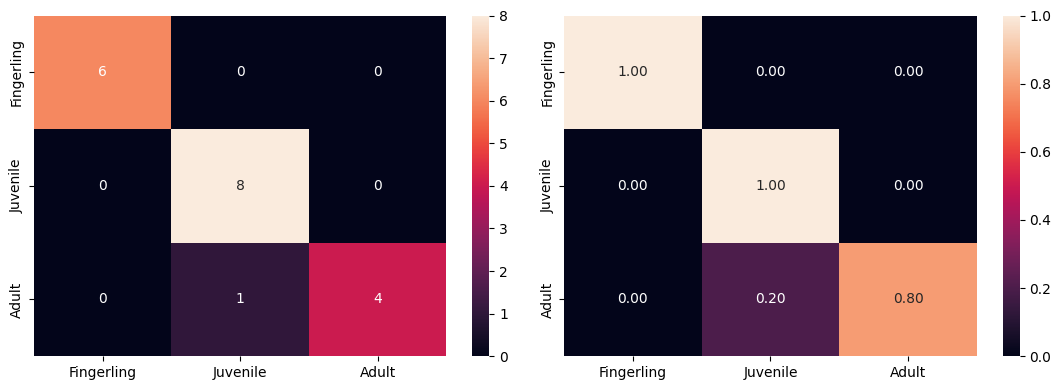

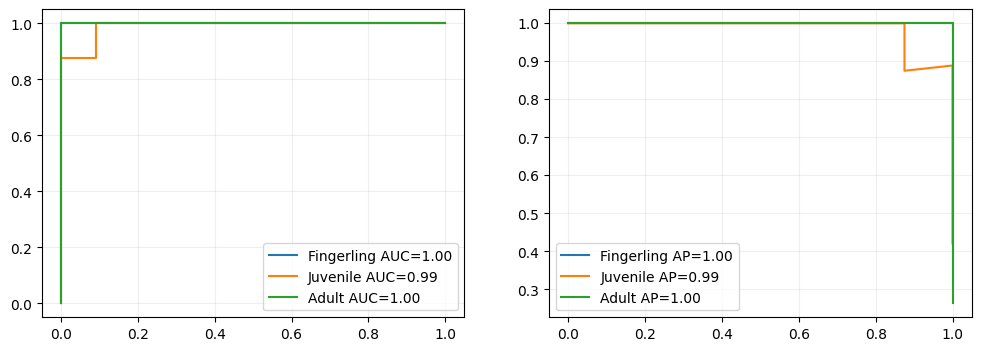

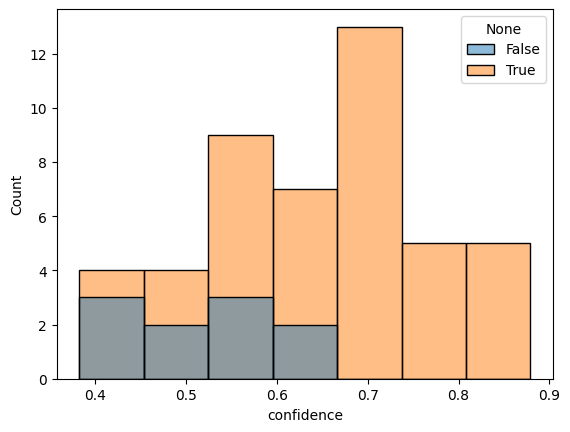

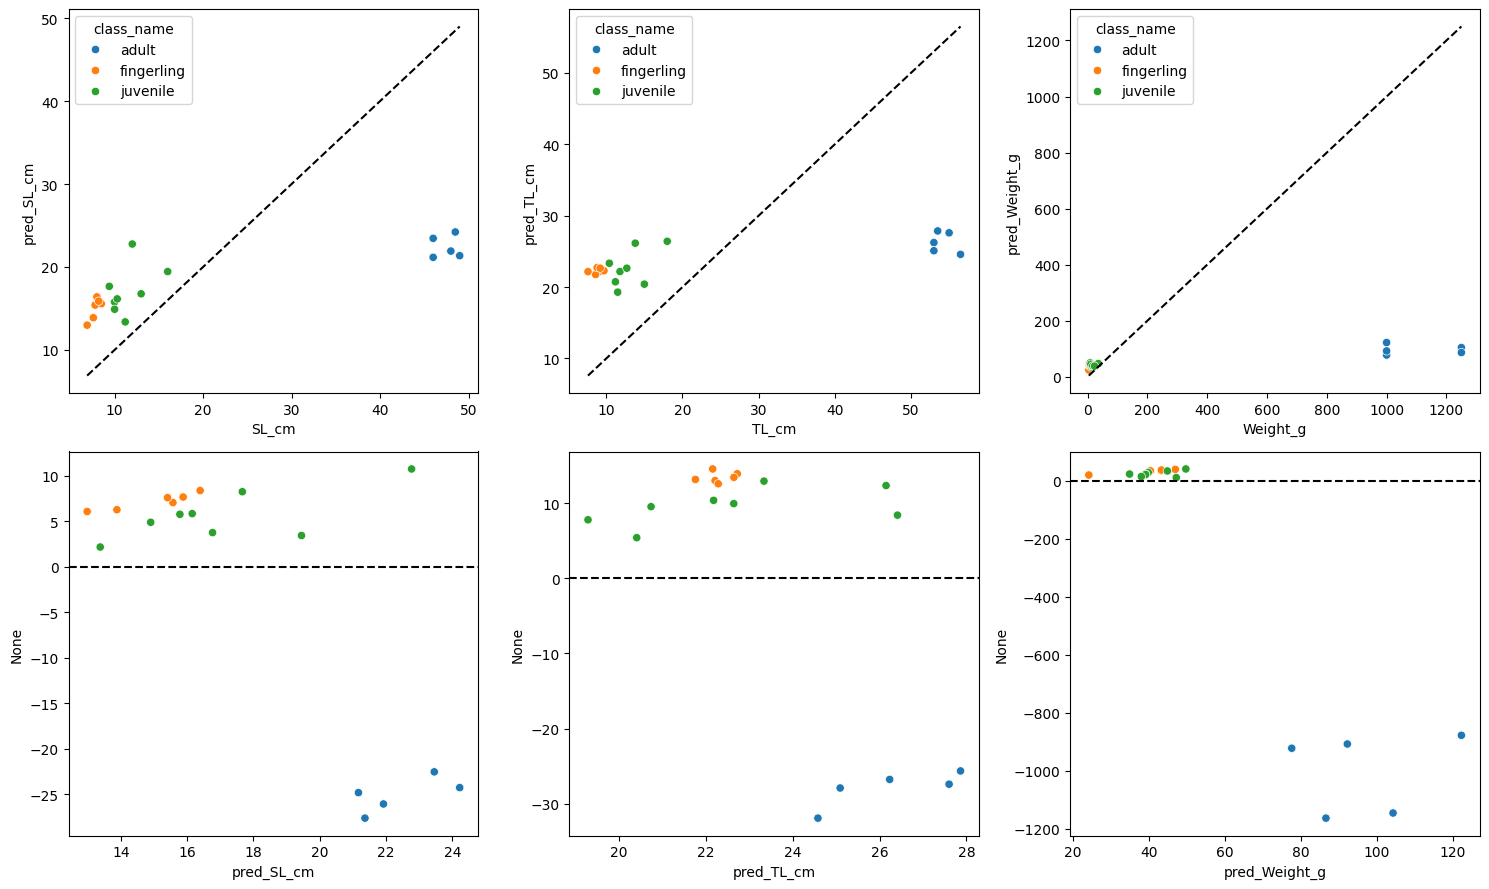

,class_name,target,MAE,RMSE
0,adult,SL_cm,25.076882,25.135243
1,adult,TL_cm,27.925763,28.007292
2,adult,Weight_g,1003.444646,1011.124087
3,fingerling,SL_cm,7.187765,7.233035
4,fingerling,TL_cm,13.449150,13.464467
5,fingerling,Weight_g,33.455094,34.033217
6,juvenile,SL_cm,5.620504,6.192696
7,juvenile,TL_cm,9.595810,9.863530
8,juvenile,Weight_g,24.707432,26.322870


,fish_id,filename,class_name,predicted_label,confidence
5,adult_020,_03.JPG,adult,1,0.658463
26,fingerling_009,_03.png,fingerling,1,0.606683
0,adult_015,_01.png,adult,1,0.560857
47,juvenile_032,_03.png,juvenile,0,0.530692
7,adult_024,_02.png,adult,1,0.526624
11,adult_029,_03.png,adult,1,0.516468
4,adult_020,_02.png,adult,1,0.466401
14,adult_030,_03.png,adult,1,0.424497
51,juvenile_043,_01.png,juvenile,2,0.409743
32,fingerling_033,_03.png,fingerling,2,0.383114


In [ ]:
cm=confusion_matrix(fish_pred.class_label,fish_pred.predicted_label,labels=[0,1,2]); cmn=cm/cm.sum(1,keepdims=True)
fig,ax=plt.subplots(1,2,figsize=(11,4)); sns.heatmap(cm,annot=True,fmt="d",xticklabels=CLASS_NAMES,yticklabels=CLASS_NAMES,ax=ax[0]); sns.heatmap(cmn,annot=True,fmt=".2f",xticklabels=CLASS_NAMES,yticklabels=CLASS_NAMES,ax=ax[1]); plt.tight_layout(); plt.savefig(OUTPUTS/"figures/confusion_matrices.png",dpi=170); plt.show()
fig,ax=plt.subplots(1,2,figsize=(12,4))
for i,n in enumerate(CLASS_NAMES):
    y=(fish_pred.class_label.values==i).astype(int); fpr,tpr,_=roc_curve(y,fp[:,i]); prec,rec,_=precision_recall_curve(y,fp[:,i]); ax[0].plot(fpr,tpr,label=f"{n} AUC={roc_auc_score(y,fp[:,i]):.2f}"); ax[1].plot(rec,prec,label=f"{n} AP={average_precision_score(y,fp[:,i]):.2f}")
for a in ax:a.legend();a.grid(alpha=.2)
plt.savefig(OUTPUTS/"figures/roc_pr_curves.png",dpi=170); plt.show()
sns.histplot(data=pred_df,x="confidence",hue=(pred_df.predicted_label==pred_df.class_label)); plt.savefig(OUTPUTS/"figures/confidence_distribution.png",dpi=170); plt.show()
if RUN_MULTITASK:
    fig,ax=plt.subplots(2,3,figsize=(15,9))
    for i,n in enumerate(TARGETS):
        sns.scatterplot(data=fish_pred,x=n,y=f"pred_{n}",hue="class_name",ax=ax[0,i]); lo=min(fish_pred[n].min(),fish_pred[f"pred_{n}"].min()); hi=max(fish_pred[n].max(),fish_pred[f"pred_{n}"].max()); ax[0,i].plot([lo,hi],[lo,hi],"k--")
        resid=fish_pred[f"pred_{n}"]-fish_pred[n]; sns.scatterplot(x=fish_pred[f"pred_{n}"],y=resid,hue=fish_pred.class_name,ax=ax[1,i],legend=False); ax[1,i].axhline(0,color="k",ls="--")
    plt.tight_layout(); plt.savefig(OUTPUTS/"figures/regression_diagnostics.png",dpi=170); plt.show()
    by_class=[]
    for cls,g in fish_pred.groupby("class_name"):
        for n in TARGETS: by_class.append({"class_name":cls,"target":n,"MAE":mean_absolute_error(g[n],g[f"pred_{n}"]),"RMSE":mean_squared_error(g[n],g[f"pred_{n}"])**.5})
    pd.DataFrame(by_class).to_csv(OUTPUTS/"reports/regression_by_class.csv",index=False); display(pd.DataFrame(by_class))
display(pred_df[pred_df.predicted_label!=pred_df.class_label].sort_values("confidence",ascending=False).head(12)[["fish_id","filename","class_name","predicted_label","confidence"]])


## 25. Grad-CAM explainability

In [ ]:
import cv2
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from pathlib import Path
from PIL import Image


def resolve_image_path(path_value):
    """
    Validate and resolve an image path stored in pred_df.
    """
    image_path = Path(str(path_value))

    if image_path.exists():
        return image_path

    # Try resolving relative paths from /content.
    colab_path = Path("/content") / str(path_value)

    if colab_path.exists():
        return colab_path

    raise FileNotFoundError(
        f"Image does not exist.\n"
        f"Original path: {path_value}\n"
        f"Checked: {image_path}\n"
        f"Checked: {colab_path}"
    )


def get_class_output_tensor(model):
    """
    Identify the classification output safely.
    """

    if isinstance(model.output, dict):
        if "class_output" in model.output:
            return model.output["class_output"]

        raise ValueError(
            "The model output is a dictionary, but class_output "
            "was not found."
        )

    if isinstance(model.output, (list, tuple)):
        output_names = list(model.output_names)

        if "class_output" in output_names:
            index = output_names.index("class_output")
            return model.output[index]

        for tensor in model.output:
            shape = tensor.shape

            if (
                len(shape) == 2
                and shape[-1] is not None
                and int(shape[-1]) == len(CLASS_NAMES)
            ):
                return tensor

        raise ValueError(
            "Could not identify the classification output. "
            f"Available outputs: {output_names}"
        )

    return model.output


def collect_conv_layers(layer, prefix=""):
    """
    Recursively collect Conv2D-like layers from both flattened and
    nested Keras models without using next().
    """
    collected = []

    if isinstance(
        layer,
        (
            tf.keras.layers.Conv2D,
            tf.keras.layers.DepthwiseConv2D,
            tf.keras.layers.SeparableConv2D,
        )
    ):
        output_shape = getattr(layer.output, "shape", None)

        if output_shape is not None and len(output_shape) == 4:
            collected.append(
                {
                    "layer": layer,
                    "name": f"{prefix}{layer.name}",
                    "nested": bool(prefix)
                }
            )

    if isinstance(layer, tf.keras.Model):
        nested_prefix = f"{prefix}{layer.name}/"

        for child_layer in layer.layers:
            collected.extend(
                collect_conv_layers(
                    child_layer,
                    prefix=nested_prefix
                )
            )

    return collected


def find_gradcam_layer(model, preferred_names=None):
    """
    Select a suitable convolutional layer.

    Prefer layers with useful spatial dimensions instead of blindly
    selecting the final convolution.
    """
    preferred_names = preferred_names or [
        "block7a_project_conv",
        "block6d_project_conv",
        "block6c_project_conv",
        "top_conv"
    ]

    candidates = []

    for layer in model.layers:
        candidates.extend(
            collect_conv_layers(layer)
        )

    if not candidates:
        raise RuntimeError(
            "No convolutional feature layer was found in the model."
        )

    # First try preferred EfficientNet layers.
    for preferred_name in preferred_names:
        for candidate in candidates:
            if candidate["layer"].name == preferred_name:
                return candidate

    # Prefer a late feature layer with a spatial output.
    spatial_candidates = []

    for candidate in candidates:
        shape = candidate["layer"].output.shape

        if len(shape) != 4:
            continue

        height = shape[1]
        width = shape[2]

        if (
            height is not None
            and width is not None
            and int(height) >= 5
            and int(width) >= 5
        ):
            spatial_candidates.append(candidate)

    if spatial_candidates:
        return spatial_candidates[-1]

    return candidates[-1]


def prepare_gradcam_input(image_path):
    """
    Use the same resize-with-padding procedure as the training pipeline.
    """
    image_bytes = tf.io.read_file(str(image_path))

    image = tf.io.decode_image(
        image_bytes,
        channels=3,
        expand_animations=False
    )

    image = tf.image.resize_with_pad(
        image,
        IMAGE_SIZE,
        IMAGE_SIZE
    )

    image = tf.cast(image, tf.float32)

    image.set_shape([
        IMAGE_SIZE,
        IMAGE_SIZE,
        3
    ])

    return image[None, ...]


def build_flat_gradcam_model(
    model,
    target_layer,
    class_output
):
    """
    Build Grad-CAM for a convolutional layer directly connected to
    the outer model graph.
    """
    return tf.keras.Model(
        inputs=model.inputs,
        outputs=[
            target_layer.output,
            class_output
        ],
        name="flat_gradcam_model"
    )


def build_nested_gradcam_models(
    model,
    nested_model,
    target_layer,
    class_output
):
    """
    Handle a backbone stored as a nested Keras model.
    """
    feature_extractor = tf.keras.Model(
        inputs=nested_model.inputs,
        outputs=[
            target_layer.output,
            nested_model.output
        ],
        name="nested_feature_extractor"
    )

    nested_index = model.layers.index(nested_model)

    head_input = tf.keras.Input(
        shape=nested_model.output.shape[1:],
        name="gradcam_head_input"
    )

    x = head_input

    for layer in model.layers[nested_index + 1:]:
        x = layer(x, training=False)

    head_model = tf.keras.Model(
        head_input,
        x,
        name="gradcam_head_model"
    )

    return feature_extractor, head_model


def make_gradcam_heatmap(
    model,
    image_path,
    class_index=None,
    preferred_layer_names=None
):
    image_path = resolve_image_path(image_path)
    input_array = prepare_gradcam_input(image_path)

    class_output = get_class_output_tensor(model)

    selected = find_gradcam_layer(
        model,
        preferred_names=preferred_layer_names
    )

    target_layer = selected["layer"]

    print(
        "Grad-CAM target layer:",
        selected["name"],
        "| output shape:",
        target_layer.output.shape
    )

    # Find whether the selected layer belongs to a nested model.
    parent_model = None

    for outer_layer in model.layers:
        if not isinstance(outer_layer, tf.keras.Model):
            continue

        if target_layer in outer_layer.layers:
            parent_model = outer_layer
            break

    if parent_model is None:
        # Flattened model.
        grad_model = build_flat_gradcam_model(
            model,
            target_layer,
            class_output
        )

        with tf.GradientTape() as tape:
            feature_maps, predictions = grad_model(
                input_array,
                training=False
            )

            if isinstance(predictions, dict):
                predictions = predictions["class_output"]

            if isinstance(predictions, (list, tuple)):
                predictions = predictions[0]

            if class_index is None:
                class_index = int(
                    tf.argmax(predictions[0]).numpy()
                )

            score = predictions[:, class_index]

    else:
        # Nested backbone model.
        feature_extractor, head_model = (
            build_nested_gradcam_models(
                model=model,
                nested_model=parent_model,
                target_layer=target_layer,
                class_output=class_output
            )
        )

        # Pass input through layers before the nested backbone.
        x = input_array
        nested_index = model.layers.index(parent_model)

        for layer in model.layers[1:nested_index]:
            x = layer(x, training=False)

        with tf.GradientTape() as tape:
            feature_maps, backbone_output = feature_extractor(
                x,
                training=False
            )

            tape.watch(feature_maps)

            predictions = head_model(
                backbone_output,
                training=False
            )

            if isinstance(predictions, dict):
                predictions = predictions["class_output"]

            if isinstance(predictions, (list, tuple)):
                predictions = predictions[0]

            if class_index is None:
                class_index = int(
                    tf.argmax(predictions[0]).numpy()
                )

            score = predictions[:, class_index]

    gradients = tape.gradient(
        score,
        feature_maps
    )

    if gradients is None:
        raise RuntimeError(
            f"No gradients were produced for layer "
            f"'{selected['name']}'. Try an earlier convolutional layer."
        )

    pooled_gradients = tf.reduce_mean(
        gradients,
        axis=(0, 1, 2)
    )

    feature_maps = feature_maps[0]

    heatmap = tf.reduce_sum(
        feature_maps
        * pooled_gradients[None, None, :],
        axis=-1
    )

    heatmap = tf.nn.relu(heatmap)

    heatmap_max = tf.reduce_max(heatmap)

    if float(heatmap_max) > 0:
        heatmap = heatmap / heatmap_max

    return {
        "heatmap": heatmap.numpy(),
        "class_index": int(class_index),
        "layer_name": selected["name"],
        "predictions": predictions[0].numpy()
    }


def create_gradcam_overlay(
    image_path,
    heatmap,
    alpha=0.40
):
    image_path = resolve_image_path(image_path)

    raw_bgr = cv2.imread(str(image_path))

    if raw_bgr is None:
        raise ValueError(
            f"OpenCV could not decode image: {image_path}"
        )

    raw_rgb = cv2.cvtColor(
        raw_bgr,
        cv2.COLOR_BGR2RGB
    )

    resized_heatmap = cv2.resize(
        heatmap,
        (
            raw_rgb.shape[1],
            raw_rgb.shape[0]
        )
    )

    resized_heatmap = np.uint8(
        np.clip(
            resized_heatmap,
            0,
            1
        ) * 255
    )

    coloured_heatmap = cv2.applyColorMap(
        resized_heatmap,
        cv2.COLORMAP_JET
    )

    coloured_heatmap = cv2.cvtColor(
        coloured_heatmap,
        cv2.COLOR_BGR2RGB
    )

    overlay = cv2.addWeighted(
        raw_rgb,
        1.0 - alpha,
        coloured_heatmap,
        alpha,
        0
    )

    return overlay


def gradcam(
    model,
    image_path,
    class_index=None,
    preferred_layer_names=None
):
    result = make_gradcam_heatmap(
        model=model,
        image_path=image_path,
        class_index=class_index,
        preferred_layer_names=preferred_layer_names
    )

    overlay = create_gradcam_overlay(
        image_path=image_path,
        heatmap=result["heatmap"]
    )

    return overlay, result


print("Corrected Grad-CAM functions loaded.")

Corrected Grad-CAM functions loaded.


Grad-CAM failure for /content/catfish_dataset/catfish_dataset/fish/adult/adult_015/_02.png: TypeError("gradcam() got an unexpected keyword argument 'class_index'")
Grad-CAM failure for /content/catfish_dataset/catfish_dataset/fish/fingerling/fingerlin_002/_01.png: TypeError("gradcam() got an unexpected keyword argument 'class_index'")
Grad-CAM failure for /content/catfish_dataset/catfish_dataset/fish/juvenile/juvenile_010/_01.png: TypeError("gradcam() got an unexpected keyword argument 'class_index'")
Grad-CAM failure for /content/catfish_dataset/catfish_dataset/fish/adult/adult_020/_03.JPG: TypeError("gradcam() got an unexpected keyword argument 'class_index'")
Grad-CAM failure for /content/catfish_dataset/catfish_dataset/fish/fingerling/fingerlin_009/_03.png: TypeError("gradcam() got an unexpected keyword argument 'class_index'")
Grad-CAM failure for /content/catfish_dataset/catfish_dataset/fish/adult/adult_015/_01.png: TypeError("gradcam() got an unexpected keyword argument 'class_i

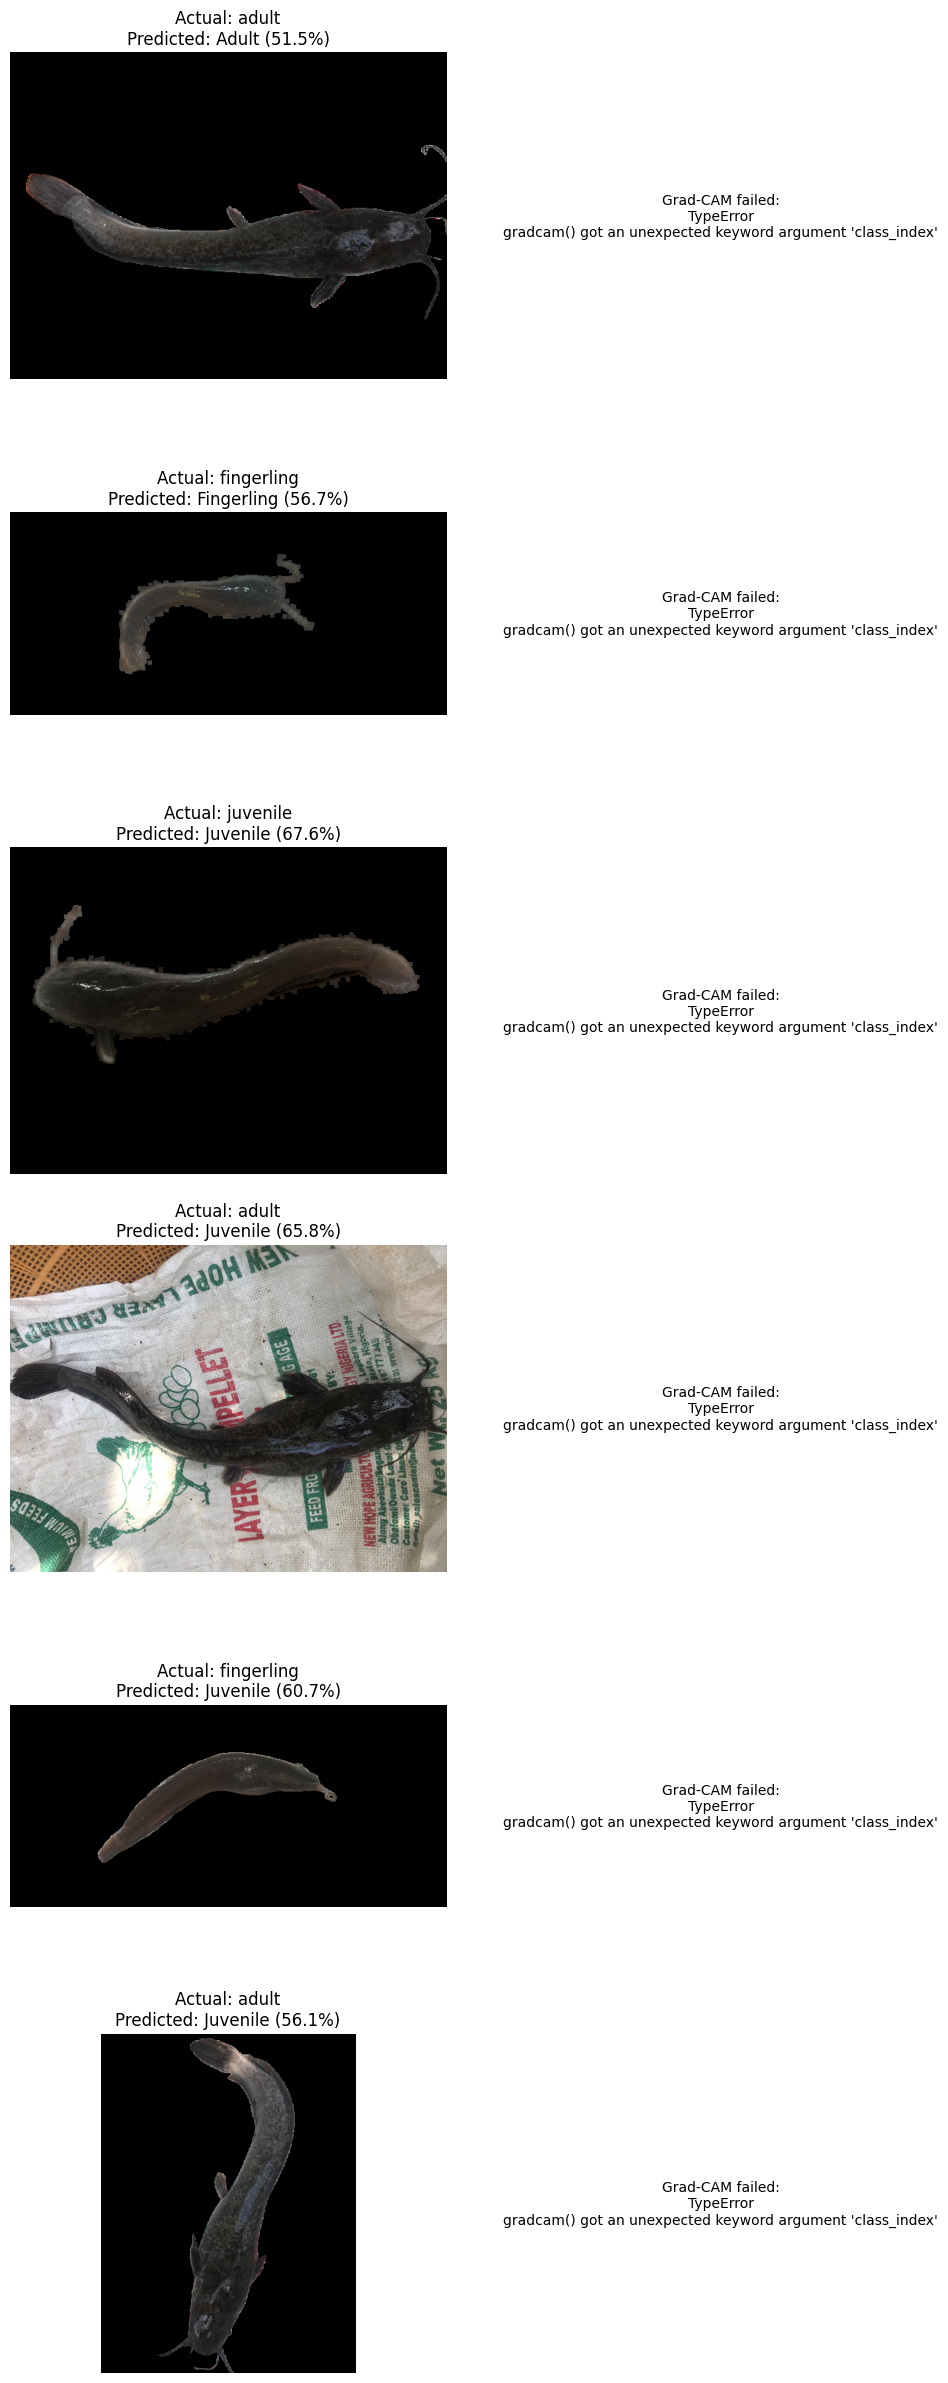

Successful Grad-CAM images: 0/6
Saved to: /content/outputs/explainability/gradcam_examples.png


In [ ]:
if RUN_GRADCAM:
    correct_examples = (
        pred_df[
            pred_df["predicted_label"]
            == pred_df["class_label"]
        ]
        .groupby(
            "class_name",
            group_keys=False
        )
        .head(1)
    )

    incorrect_examples = (
        pred_df[
            pred_df["predicted_label"]
            != pred_df["class_label"]
        ]
        .sort_values(
            "confidence",
            ascending=False
        )
        .head(3)
    )

    examples = (
        pd.concat(
            [
                correct_examples,
                incorrect_examples
            ],
            ignore_index=True
        )
        .drop_duplicates(
            subset=BEST_PATH_COL
        )
    )

    if examples.empty:
        print("No Grad-CAM examples were available.")

    else:
        rows = len(examples)

        figure, axes = plt.subplots(
            rows,
            2,
            figsize=(10, 4 * rows),
            squeeze=False
        )

        success_count = 0

        for plot_index, (_, row) in enumerate(
            examples.iterrows()
        ):
            raw_axis = axes[plot_index, 0]
            cam_axis = axes[plot_index, 1]

            try:
                image_path = resolve_image_path(
                    row[BEST_PATH_COL]
                )

                original = Image.open(
                    image_path
                ).convert("RGB")

                raw_axis.imshow(original)

                predicted_index = int(
                    row["predicted_label"]
                )

                predicted_name = CLASS_NAMES[
                    predicted_index
                ]

                raw_axis.set_title(
                    f"Actual: {row['class_name']}\n"
                    f"Predicted: {predicted_name} "
                    f"({float(row['confidence']):.1%})"
                )

            except Exception as image_error:
                image_path = None

                raw_axis.text(
                    0.5,
                    0.5,
                    "Image loading failed:\n"
                    f"{type(image_error).__name__}\n"
                    f"{image_error}",
                    ha="center",
                    va="center",
                    wrap=True
                )

            if image_path is not None:
                try:
                    overlay, result = gradcam(
                        model=final_model,
                        image_path=image_path,
                        class_index=predicted_index,
                        preferred_layer_names=[
                            "block7a_project_conv",
                            "block6d_project_conv",
                            "block6c_project_conv",
                            "top_conv"
                        ]
                    )

                    cam_axis.imshow(overlay)

                    cam_axis.set_title(
                        "Grad-CAM\n"
                        f"Layer: {result['layer_name']}"
                    )

                    success_count += 1

                except Exception as gradcam_error:
                    cam_axis.text(
                        0.5,
                        0.5,
                        "Grad-CAM failed:\n"
                        f"{type(gradcam_error).__name__}\n"
                        f"{gradcam_error}",
                        ha="center",
                        va="center",
                        wrap=True
                    )

                    print(
                        f"Grad-CAM failure for {image_path}:",
                        repr(gradcam_error)
                    )

            raw_axis.axis("off")
            cam_axis.axis("off")

        plt.tight_layout()

        output_path = (
            OUTPUTS
            / "explainability"
            / "gradcam_examples.png"
        )

        output_path.parent.mkdir(
            parents=True,
            exist_ok=True
        )

        plt.savefig(
            output_path,
            dpi=170,
            bbox_inches="tight"
        )

        plt.show()

        print(
            f"Successful Grad-CAM images: "
            f"{success_count}/{rows}"
        )

        print(
            "Saved to:",
            output_path
        )

In [ ]:
import inspect

gradcam_source = inspect.getsource(gradcam)

print(
    "Old nested next() still present:",
    "next(" in gradcam_source
)

Old nested next() still present: False


## 28–29. Production inference and saved-model reload verification

In [ ]:
_MODEL_CACHE={}
def predict_catfish(image_path,model_path=MULTI_PATH):
    p=Path(image_path)
    if not p.is_file(): raise FileNotFoundError(f"Image not found: {p}")
    try: img=Image.open(p).convert("RGB")
    except Exception as e: raise ValueError(f"Unreadable image {p}: {e}")
    use_path=p
    if BEST_PATH_COL=="crop_path":
        tmp=OUTPUTS/"crops/inference_crop.png"; conservative_crop(p,tmp); use_path=tmp
    raw=tf.convert_to_tensor(np.asarray(Image.open(use_path).convert("RGB"))); arr=tf.image.resize_with_pad(raw,IMAGE_SIZE,IMAGE_SIZE)[None]
    key=str(model_path)
    if key not in _MODEL_CACHE: _MODEL_CACHE[key]=tf.keras.models.load_model(model_path,compile=False)
    out=_MODEL_CACHE[key].predict(arr,verbose=0); prob=np.asarray(out[0])[0]
    z=np.array([[np.ravel(out[1])[0],np.ravel(out[2])[0],np.ravel(out[3])[0]]]); measures=inverse_reg(z)[0]; label=int(prob.argmax())
    return {"predicted_class":CLASS_NAMES[label],"class_label":label,"confidence":float(prob[label]),"class_probabilities":{n:float(prob[i]) for i,n in enumerate(CLASS_NAMES)},"SL_cm":float(measures[0]),"TL_cm":float(measures[1]),"Weight_g":float(measures[2])}

before=np.asarray(final_model.predict(make_ds(test.head(3),path_col=BEST_PATH_COL),verbose=0)[0]); del final_model; tf.keras.backend.clear_session(); gc.collect(); _MODEL_CACHE.clear()
reloaded=tf.keras.models.load_model(MULTI_PATH,compile=False); after=np.asarray(reloaded.predict(make_ds(test.head(3),path_col=BEST_PATH_COL),verbose=0)[0]); assert np.allclose(before,after,rtol=1e-5,atol=1e-6)
print("Saved-model reload verified on three test images.")
for p in test.head(3).image_path: print(predict_catfish(p))


Saved-model reload verified on three test images.
{'predicted_class': 'Juvenile', 'class_label': 1, 'confidence': 0.5608577132225037, 'class_probabilities': {'Fingerling': 0.10182330757379532, 'Juvenile': 0.5608577132225037, 'Adult': 0.33731895685195923}, 'SL_cm': 23.41643714904785, 'TL_cm': 25.919967651367188, 'Weight_g': 76.10893249511719}
{'predicted_class': 'Adult', 'class_label': 2, 'confidence': 0.5148541927337646, 'class_probabilities': {'Fingerling': 0.11228624731302261, 'Juvenile': 0.37285956740379333, 'Adult': 0.5148541927337646}, 'SL_cm': 25.354400634765625, 'TL_cm': 27.787893295288086, 'Weight_g': 109.33916473388672}
{'predicted_class': 'Adult', 'class_label': 2, 'confidence': 0.8213359713554382, 'class_probabilities': {'Fingerling': 0.06557513028383255, 'Juvenile': 0.11308897286653519, 'Adult': 0.8213359713554382}, 'SL_cm': 23.88394546508789, 'TL_cm': 29.09282112121582, 'Weight_g': 127.24241638183594}


## 30–32. Final summary, Drive copy, and downloadable outputs

In [ ]:
summary={"images":len(index),"independent_fish":index.fish_id.nunique(),"class_images":index.class_name.value_counts().to_dict(),"class_fish":index.groupby("class_name").fish_id.nunique().to_dict(),"splits":{k:{"images":len(v),"fish":v.fish_id.nunique()} for k,v in splits.items()},"fish_leakage":"PASS: zero overlap","best_classification_backbone":str(BEST_BACKBONE),"best_preprocessing":str(BEST_PATH_COL),"best_imbalance_strategy":str(best_exp.balancing),"best_validation_accuracy":float(best_exp.val_accuracy),"best_validation_macro_f1":float(best_exp.val_macro_f1),"validation_juvenile_recall":float(best_exp.juvenile_recall),"image_test_metrics":image_metrics,"fish_test_metrics":fish_metrics,"fish_regression_metrics":reg_metrics,"bootstrap_95pct_CI":cis,"test_accuracy_exceeded_90pct":bool(fish_metrics["accuracy"]>.90),"regression_beat_class_mean_baseline":regression_beats_baseline,"limitations":["Only 117 independent fish","Absolute size may be confounded by camera distance/background/reference objects","Grouped test contains only 19 fish; confidence intervals may be wide"]}
json.dump(summary,open(OUTPUTS/"reports/final_summary.json","w"),indent=2); pd.json_normalize(summary).to_csv(OUTPUTS/"reports/final_summary.csv",index=False)
json.dump({str(v):k for k,v in CLASS_MAPPING.items()},open(OUTPUTS/"models/class_mapping.json","w"),indent=2)
print(json.dumps(summary,indent=2)); print("Reminder: 357 images represent only 117 independent fish.")
archive=shutil.make_archive("/content/catfish_multitask_outputs","zip","/content/outputs")
if USE_GOOGLE_DRIVE:
    dest=Path("/content/drive/MyDrive/catfish_multitask_outputs");
    if dest.exists(): shutil.rmtree(dest)
    shutil.copytree(OUTPUTS,dest); print("Copied outputs to",dest)
else:
    print("Output archive:",archive)
    from google.colab import files
    files.download(archive)


{
  "images": 357,
  "independent_fish": 117,
  "class_images": {
    "juvenile": 147,
    "fingerling": 106,
    "adult": 104
  },
  "class_fish": {
    "adult": 33,
    "fingerling": 35,
    "juvenile": 49
  },
  "splits": {
    "train": {
      "images": 249,
      "fish": 81
    },
    "validation": {
      "images": 51,
      "fish": 17
    },
    "test": {
      "images": 57,
      "fish": 19
    }
  },
  "fish_leakage": "PASS: zero overlap",
  "best_classification_backbone": "EfficientNetB0",
  "best_preprocessing": "image_path",
  "best_imbalance_strategy": "class_weights",
  "best_validation_accuracy": 0.9215686274509803,
  "best_validation_macro_f1": 0.9238095238095237,
  "validation_juvenile_recall": 0.9047619047619048,
  "image_test_metrics": {
    "accuracy": 0.8245614035087719,
    "balanced_accuracy": 0.8018518518518518,
    "macro_precision": 0.839326326141742,
    "macro_recall": 0.8018518518518518,
    "macro_f1": 0.8122606952795633,
    "weighted_f1": 0.8204611674323

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Optional: upload a new image for inference

Run after training and model reload verification.

In [ ]:
from google.colab import files
new_upload=files.upload()
for name in new_upload:
    print(predict_catfish(Path("/content")/name))
